# FLUX guidelines across Oxford and Princeton OPM-MEG

This notebook applies a matched OPM-FLUX workflow to the bundled Oxford participant (`oxford_sub-01`) and a configurable Princeton participant (default: `princeton_sub-024`). Its purpose is **comparative data-quality assessment**, not a group-level neuroscientific inference: the participants, tasks, response mappings, laboratories, and mains frequencies differ.

Primary comparison:

- Oxford: all response events beginning with `resp` (`resp_T` and `resp_L`) are **pooled**, never contrasted outside MVPA.
- Princeton: `response/right` only, after excluding the first 450 s of training.
- Both: the same post-training duration, radial Z channels, second-order HFC, the same artefact rules, ICA strategy, continuous filter, response epoch, rejection threshold, ERF/TFR settings, and source regularisation.

The Oxford T/L labels distinguish two fingers of one hand, whereas Princeton right/left labels distinguish hands. Their category contrasts are therefore used **only as separate within-dataset MVPA quality checks**. ERF, TFR, LCMV, DICS, and all other comparisons use the pooled/single-condition response selections above.

Change `PRINCETON_DATASET` in the setup cell to analyse another identically structured folder such as `princeton_sub-038`. Every displayed Matplotlib figure is also saved as a PNG under `outputs/flux_oxford_princeton/<Princeton dataset>/`.

`SHARED_BLINK_DETECTOR` (default `True`) detects blinks on the same frontal OPM surrogate at both sites. Set it to `False` to use Princeton's best-matching native EOG component instead; outputs then go to `outputs/flux_oxford_princeton/<Princeton dataset>_native-eog/`.

> Interpretation guardrail: direct amplitude differences can reflect participant anatomy, sensor placement, task design, and trial count as well as hardware/data quality. Baseline-normalised measures and matched-duration summaries are therefore shown alongside physical units.


## 1. Introduction and installation

The tested project environment is defined by `pyproject.toml`/`uv.lock`. From the repository root, install it with:

```bash
uv sync
```

The analysis uses MNE-Python, NumPy, pandas, SciPy, Matplotlib, and scikit-learn. It is non-interactive so the executed notebook remains portable and all figures embed correctly.

In [1]:
import os
import tempfile
from pathlib import Path
from IPython.display import display, Markdown

# Keep package caches writable in restricted/containerised environments.
os.environ.setdefault("MNE_DONTWRITE_HOME", "true")
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "flux-mpl"))
os.environ.setdefault("MNE_TQDM", "off")

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

from scipy.stats import median_abs_deviation
from scipy.signal import resample_poly
from sklearn.base import clone
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

mne.set_log_level("WARNING")
warnings.filterwarnings("ignore", category=RuntimeWarning, module="mne")
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 180,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.18,
    }
)

ROOT = Path.cwd().resolve()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
OXFORD_DATASET = "oxford_sub-01"
# Change this one value for another identically structured Princeton download.
PRINCETON_DATASET = "princeton_sub-038"
PRINCETON_SUBJECT = PRINCETON_DATASET.removeprefix("princeton_sub-")
# True: detect blinks on the F9-F10 frontal OPM surrogate at both sites.
# False: Princeton uses the native EOG component that best matches the surrogate.
SHARED_BLINK_DETECTOR = True

FIG_DIR = (
    ROOT
    / "outputs"
    / "flux_oxford_princeton"
    / (PRINCETON_DATASET + ("" if SHARED_BLINK_DETECTOR else "_native-eog"))
)
FIG_DIR.mkdir(parents=True, exist_ok=True)

TARGET_SFREQ = 300.0  # preserves the 110-130 Hz muscle band
ICA_SFREQ = 250.0  # OPM-FLUX ICA recommendation
PRINCETON_CROP_START = 400.0
HFC_ORDER = 2  # matches the supplied Oxford FLUX tutorial
REJECT_MAG = 50e-12  # shared response-epoch peak-to-peak threshold
RANDOM_STATE = 99
RUN_ICA = True
RUN_SOURCE_MODELING = True

COLORS = {"Oxford": "#2B6CB0", "Princeton": "#D97706"}


def save_show(fig, stem):
    # Save a publication-ready PNG and embed the same figure in the notebook.
    path = FIG_DIR / f"{stem}.png"
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    display(fig)
    plt.close(fig)
    print(f"Saved: {path.relative_to(ROOT)}")
    return path


print("MNE:", mne.__version__)
print("Repository:", ROOT)
print("Figure directory:", FIG_DIR.relative_to(ROOT))
print("Shared blink detector:", SHARED_BLINK_DETECTOR)

MNE: 1.13.2
Repository: /Users/harrisonritz/repos/cerca-flux-tutorial
Figure directory: outputs/flux_oxford_princeton/princeton_sub-038


## 2. The datasets

Oxford is the Cerca/QuSpin spatial-attention example (1500 Hz originally; the bundled BIDS copy is already 750 Hz). Princeton is a BIDS split recording at 1200 Hz with embedded metadata, EOG channels, eyetracker channels, and a 60 Hz mains frequency. MNE follows linked Princeton FIF parts automatically when the first split is opened; all discovered paths are nevertheless audited before loading.

`PRINCETON_DATASET` is the only participant selector. The loader derives the BIDS subject label, FIF prefix, events file, BEM, transform, MRI, and output subdirectory from it, so another download with the same folder structure (for example `princeton_sub-038`) can be selected without editing analysis code.

The Oxford response label used colloquially as `resp` is represented in its event table by `resp_T` and `resp_L`; both are pooled for the main response-locked analysis. Princeton uses only `response/right`. T/L and right/left are instantiated separately only for MVPA.


In [2]:
OX_ROOT = ROOT / "data" / OXFORD_DATASET
OX_RAW = (
    OX_ROOT
    / "Data/Cerca_Spatt_BIDS/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_meg.fif"
)
OX_EVENTS = (
    OX_ROOT
    / "Data/Cerca_Spatt_BIDS/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_events.tsv"
)
PR_ROOT = ROOT / "data" / PRINCETON_DATASET
PR_MEG_DIR = PR_ROOT / "meg"
PR_PARTS = sorted(
    PR_MEG_DIR.glob(f"sub-{PRINCETON_SUBJECT}_ses-*_task-*_run-*_split-*_meg.fif")
)

assert OX_RAW.exists() and OX_EVENTS.exists(), "Oxford raw/events files were not found"
assert PR_PARTS, f"No split MEG FIF files found in {PR_MEG_DIR}"
pr_recording_prefix = PR_PARTS[0].name.rsplit("_split-", 1)[0]
assert all(p.name.startswith(pr_recording_prefix + "_split-") for p in PR_PARTS), (
    "More than one Princeton recording prefix was found; narrow the PR_PARTS glob"
)
PR_EVENTS = PR_MEG_DIR / f"{pr_recording_prefix}_events.tsv"
assert PR_EVENTS.exists(), f"Princeton events file not found: {PR_EVENTS}"


def read_events_tsv(path):
    return pd.read_csv(path, sep="\t", encoding="utf-8-sig")


def annotations_from_tsv(raw, path):
    table = read_events_tsv(path)
    ann = mne.Annotations(
        onset=table["onset"].to_numpy(float),
        duration=table["duration"].fillna(0).to_numpy(float),
        description=table["trial_type"].astype(str).to_numpy(),
        orig_time=raw.info["meas_date"],
    )
    raw.set_annotations(ann)
    return table


ox_raw = mne.io.read_raw_fif(OX_RAW, preload=False, verbose="ERROR")
# Opening the first split follows its FIFF links through the remaining parts.
pr_raw = mne.io.read_raw_fif(PR_PARTS[0], preload=False, verbose="ERROR")

event_tables = {
    "Oxford": annotations_from_tsv(ox_raw, OX_EVENTS),
    "Princeton": annotations_from_tsv(pr_raw, PR_EVENTS),
}

# Preserve full lazy headers for forward modelling, then crop equal-duration views.
source_infos = {"Oxford": ox_raw.info.copy(), "Princeton": pr_raw.info.copy()}
available_princeton = pr_raw.times[-1] - PRINCETON_CROP_START
assert available_princeton > 0, (
    "Princeton recording ends before the requested crop start"
)
matched_duration = min(ox_raw.times[-1], available_princeton)
ox_raw.crop(0, matched_duration, include_tmax=False)
pr_raw.crop(
    PRINCETON_CROP_START, PRINCETON_CROP_START + matched_duration, include_tmax=False
)
raws = {"Oxford": ox_raw, "Princeton": pr_raw}

# Freeze event times now, before resampling and artefact annotations.
decoded_events = {}
for name, raw in raws.items():
    event_samples, event_id = mne.events_from_annotations(raw, verbose="ERROR")
    event_times = (event_samples[:, 0] - raw.first_samp) / raw.info["sfreq"]
    decoded_events[name] = (event_times, event_samples[:, 2].copy(), event_id.copy())


def count_events_in_view(name, raw):
    ev, ids = mne.events_from_annotations(raw, verbose="ERROR")
    wanted = [
        k
        for k in ids
        if (k.startswith("resp") if name == "Oxford" else k == "response/right")
    ]
    return sum(np.sum(ev[:, 2] == ids[k]) for k in wanted)


overview = []
for name, raw in raws.items():
    types = pd.Series(raw.get_channel_types()).value_counts()
    overview.append(
        {
            "dataset": name,
            "sampling_hz": raw.info["sfreq"],
            "analysed_minutes": raw.times[-1] / 60,
            "mag_channels": int(types.get("mag", 0)),
            "eog_channels": int(types.get("eog", 0)),
            "metadata_bads": len(raw.info["bads"]),
            "line_hz": raw.info["line_freq"],
            "response_events": count_events_in_view(name, raw),
        }
    )
overview = pd.DataFrame(overview).set_index("dataset")
display(overview.round(2))
print(f"Selected Princeton dataset: {PRINCETON_DATASET}")
print(f"Princeton training removed: {PRINCETON_CROP_START:g} s")
print(
    f"Matched duration: {matched_duration:.1f} s ({matched_duration / 60:.1f} min per dataset)"
)
print(f"Princeton linked recording: {len(PR_PARTS)} discovered splits")


,sampling_hz,analysed_minutes,mag_channels,eog_channels,metadata_bads,line_hz,response_events
dataset,,,,,,,
Oxford,750.0,27.6,192,0,0,50.0,314
Princeton,1200.0,27.6,192,3,0,60.0,321


Selected Princeton dataset: princeton_sub-038
Princeton training removed: 400 s
Matched duration: 1655.9 s (27.6 min per dataset)
Princeton linked recording: 4 discovered splits


## 3. Down-sampling and BIDS conversion

Both inputs already have BIDS event/channel/JSON sidecars, so writing another BIDS copy would duplicate data. Events are decoded from the TSV files **before** resampling. The comparison branch later resamples in memory to 300 Hz, with MNE's anti-aliasing filter. This is high enough to retain the OPM-FLUX 110-130 Hz muscle band.

Oxford's bundled BIDS derivative is already downsampled from 1500 to 750 Hz. Princeton remains at 1200 Hz until the matched preprocessing stage. The table below is an event audit; it is an important check for overlapping or missing triggers.

,Oxford,Princeton
trial_type,,
StimOnset,360,0
cue_Left,180,0
cue_Right,180,0
dotOnLeft,162,0
dotOnRight,162,0
resp_L,147,0
resp_T,167,0
CSI,0,368
ITI,0,1769


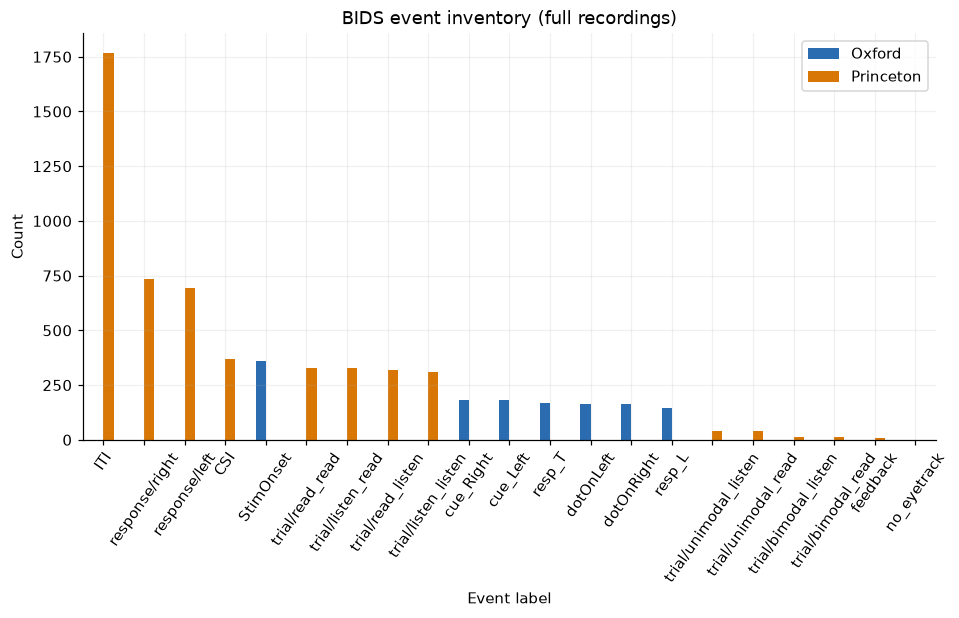

Saved: outputs/flux_oxford_princeton/princeton_sub-038/01_bids_event_inventory.png


PosixPath('/Users/harrisonritz/repos/cerca-flux-tutorial/outputs/flux_oxford_princeton/princeton_sub-038/01_bids_event_inventory.png')

In [3]:
event_audit = (
    pd.concat(
        [
            t.groupby("trial_type").size().rename(name)
            for name, t in event_tables.items()
        ],
        axis=1,
    )
    .fillna(0)
    .astype(int)
)
display(event_audit)

fig, ax = plt.subplots(figsize=(10, 4.8))
event_audit.loc[event_audit.sum(axis=1).sort_values(ascending=False).index].plot.bar(
    ax=ax, color=[COLORS["Oxford"], COLORS["Princeton"]]
)
ax.set(
    title="BIDS event inventory (full recordings)", xlabel="Event label", ylabel="Count"
)
ax.tick_params(axis="x", labelrotation=55)
save_show(fig, "01_bids_event_inventory")

## 4. A first look at the data

OPM-FLUX recommends inspecting time series, spectra, and per-sensor power before rejecting channels. Princeton's bad-channel flags are read from its FIF/BIDS metadata. For Oxford, the two sensor modules documented as faulty in the supplied tutorial (`B4`, `H6`) are added explicitly. A shared robust rule then flags unusually high-power channels within each measurement axis: median + 6 scaled MAD over 1-120 Hz. This data-adaptive rule is preferable to transferring one site's absolute 39.5 dB threshold to another acquisition.

The original first-look trace used RMS about zero. That statistic includes each OPM channel's static/DC offset and made Princeton appear roughly an order of magnitude larger. The revised trace first subtracts each channel's 10 s mean and therefore compares dynamic radial fields; the table reports both definitions so the offset contribution is explicit. This is a display correction only—the spectral QC already starts at 1 Hz, while filtering, detrending, HFC, ICA, and epoching prevent these offsets from driving later comparisons.


Oxford bad channels: ['F5 A6 X', 'F5 A6 Y', 'F5 A6 Z', 'F7 A4 X', 'F7 A4 Z', 'F8 B4 X', 'F8 B4 Y', 'F8 B4 Z', 'O4 H3 Y', 'T14 H6 X', 'T14 H6 Y', 'T14 H6 Z']
Princeton bad channels: []


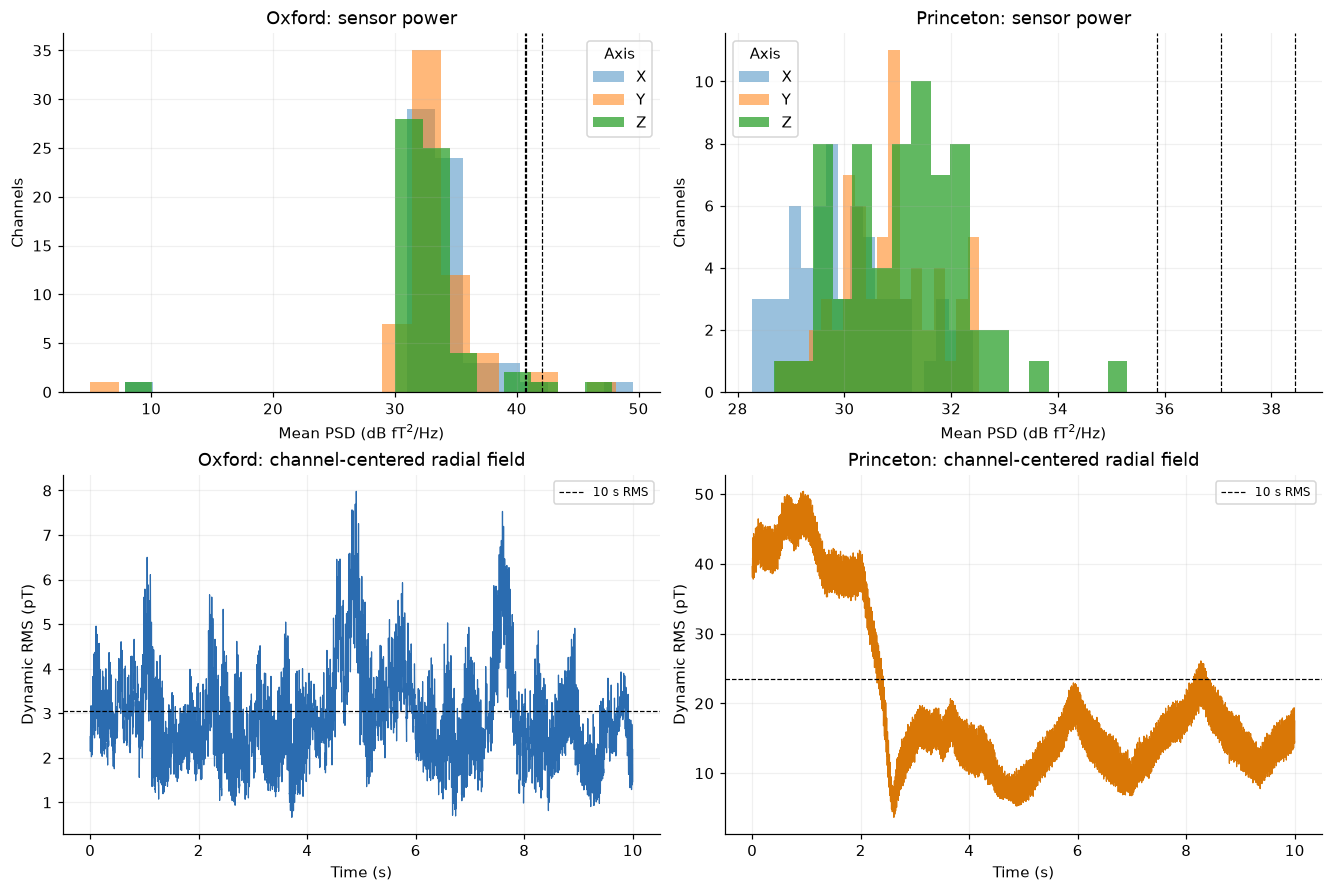

Saved: outputs/flux_oxford_princeton/princeton_sub-038/02_first_look_sensor_quality.png


,DC-inclusive_RMS_pT,channel-centered_RMS_pT,DC_inflation_factor
Oxford,3.069,3.054,1.005
Princeton,84.842,23.523,3.607


In [4]:
KNOWN_BAD_SUBSTRINGS = {"Oxford": ["B4", "H6"], "Princeton": []}


def spectrum(raw, picks, tmin=30.0, span=120.0, fmax=140.0):
    picks = [p for p in picks if p not in raw.info["bads"]]
    tmax = min(raw.times[-1], tmin + span)
    n_fft = int(round(4 * raw.info["sfreq"]))
    spec = raw.compute_psd(
        method="welch",
        fmin=1,
        fmax=min(fmax, raw.info["sfreq"] / 2 - 1),
        tmin=min(tmin, tmax - 1),
        tmax=tmax,
        picks=picks,
        n_fft=n_fft,
        n_overlap=n_fft // 2,
        reject_by_annotation=False,
        verbose="ERROR",
    )
    values = spec.get_data(picks=picks, exclude=[])
    return (
        spec.freqs,
        10 * np.log10(np.maximum(values, np.finfo(float).tiny) * 1e30),
        picks,
    )


sensor_qc = {}
for name, raw in raws.items():
    known = [
        ch
        for ch in raw.ch_names
        if any(tag in ch for tag in KNOWN_BAD_SUBSTRINGS[name])
    ]
    raw.info["bads"] = sorted(set(raw.info["bads"]) | set(known))
    meg = [ch for ch, typ in zip(raw.ch_names, raw.get_channel_types()) if typ == "mag"]
    freqs, psd_db, names = spectrum(raw, meg, fmax=120)
    mean_db = psd_db.mean(axis=1)
    robust_z = np.zeros_like(mean_db)
    threshold_db = {}
    for axis in "XYZ":
        idx = np.array([i for i, ch in enumerate(names) if ch.endswith(f" {axis}")])
        med = np.median(mean_db[idx])
        scale = 1.4826 * median_abs_deviation(mean_db[idx], scale=1.0)
        scale = max(scale, 1e-6)
        robust_z[idx] = (mean_db[idx] - med) / scale
        threshold_db[axis] = med + 6 * scale
    auto_bad = [ch for ch, z in zip(names, robust_z) if z > 6]
    raw.info["bads"] = sorted(set(raw.info["bads"]) | set(auto_bad))
    sensor_qc[name] = dict(
        freqs=freqs,
        psd_db=psd_db,
        names=names,
        mean_db=mean_db,
        robust_z=robust_z,
        auto_bad=auto_bad,
        threshold_db=threshold_db,
    )
    print(name, "bad channels:", raw.info["bads"])

first_look_rms = {}
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
for col, (name, raw) in enumerate(raws.items()):
    q = sensor_qc[name]
    for axis, alpha in zip("XYZ", [0.45, 0.55, 0.75]):
        vals = [v for v, ch in zip(q["mean_db"], q["names"]) if ch.endswith(f" {axis}")]
        axes[0, col].hist(vals, bins=18, alpha=alpha, label=axis)
        axes[0, col].axvline(q["threshold_db"][axis], color="k", lw=0.8, ls="--")
    axes[0, col].set(
        title=f"{name}: sensor power",
        xlabel=r"Mean PSD (dB fT$^2$/Hz)",
        ylabel="Channels",
    )
    axes[0, col].legend(title="Axis")

    z_names = [ch for ch in q["names"] if ch.endswith(" Z")]
    picks = [raw.ch_names.index(ch) for ch in z_names if ch not in raw.info["bads"]]
    start = int(40 * raw.info["sfreq"])
    stop = int(50 * raw.info["sfreq"])
    data, times = raw[picks, start:stop]
    absolute_rms = np.sqrt(np.mean(data**2)) * 1e12
    centered = data - data.mean(axis=1, keepdims=True)
    dynamic_rms = np.sqrt(np.mean(centered**2)) * 1e12
    first_look_rms[name] = {
        "DC-inclusive_RMS_pT": float(absolute_rms),
        "channel-centered_RMS_pT": float(dynamic_rms),
        "DC_inflation_factor": float(absolute_rms / max(dynamic_rms, 1e-15)),
    }
    instantaneous_rms = np.sqrt(np.mean(centered**2, axis=0)) * 1e12
    axes[1, col].plot(times - times[0], instantaneous_rms, color=COLORS[name], lw=0.8)
    axes[1, col].axhline(dynamic_rms, color="k", ls="--", lw=0.8, label="10 s RMS")
    axes[1, col].set(
        title=f"{name}: channel-centered radial field",
        xlabel="Time (s)",
        ylabel="Dynamic RMS (pT)",
    )
    axes[1, col].legend(fontsize=8)
save_show(fig, "02_first_look_sensor_quality")
display(pd.DataFrame(first_look_rms).T.round(3))


## 5. Artefact attenuation by HFC

Homogeneous Field Correction models spatially smooth external interference and projects it out. Second-order HFC is computed from each site's sensor geometry after bad-channel exclusion. The diagnostic uses the same 120 s interval at each site. For the full workflow, temporal resampling and the fixed spatial projection are linear operations; resampling first avoids loading the entire 1200 Hz Princeton recording into memory without changing the spatial HFC model.

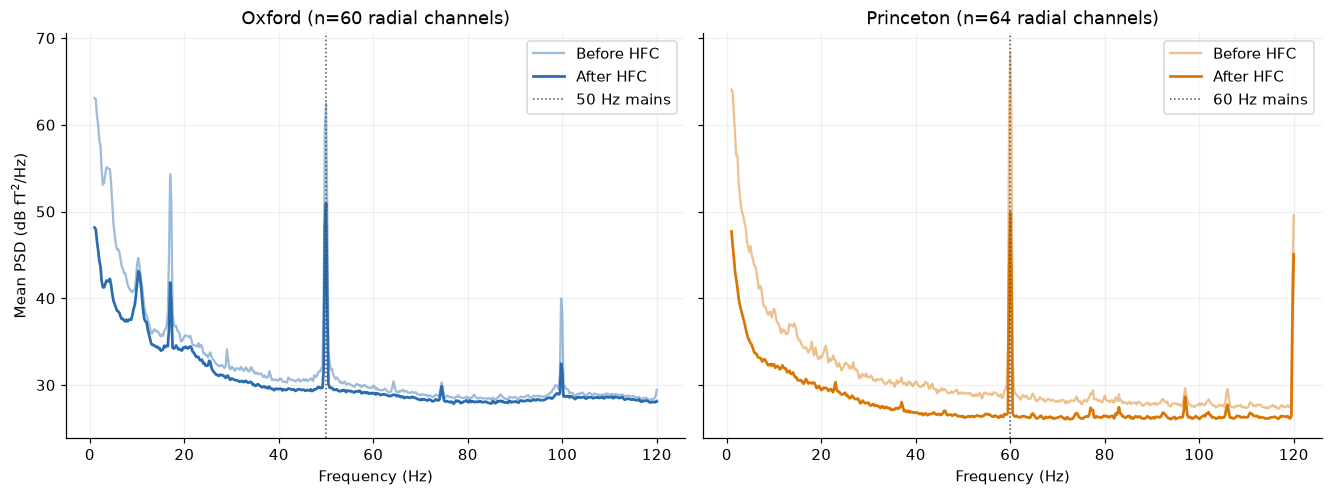

Saved: outputs/flux_oxford_princeton/princeton_sub-038/03_hfc_psd_comparison.png


,n_hfc_projs,hfc_reduction_db_1_40,line_excess_db_before,line_excess_db_after,psd_before_db,psd_after_db
Oxford,8.0,1.44,11.28,6.11,37.87,34.59
Princeton,8.0,3.66,13.18,6.37,35.84,30.68


In [5]:
def add_hfc(raw):
    out = raw.copy()
    projs = mne.preprocessing.compute_proj_hfc(
        out.info, order=HFC_ORDER, exclude="bads", verbose="ERROR"
    )
    out.add_proj(projs).apply_proj(verbose="ERROR")
    return out, projs


# def add_hfc(raw):
#     out = raw.copy()
#     mf = dict(
#         int_order=10,
#         ext_order=2,
#         ignore_ref=True,
#         bad_condition="warning",
#         st_duration=30.0,
#         st_correlation=0.90,
#         st_overlap=True,
#     )
#     out_f = mne.preprocessing.maxwell_filter(out, coord_frame="head", **mf)
#     projs = []
#     return out_f, projs


def radial_names(raw):
    return [
        ch
        for ch, typ in zip(raw.ch_names, raw.get_channel_types())
        if typ == "mag" and ch.endswith(" Z") and ch not in raw.info["bads"]
    ]


hfc_diagnostics = {}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True, constrained_layout=True)
for ax, (name, raw) in zip(axes, raws.items()):
    z = radial_names(raw)
    f0, p0, _ = spectrum(raw, z, fmax=120)
    hfc_lazy, projs = add_hfc(raw)
    f1, p1, _ = spectrum(hfc_lazy, z, fmax=120)
    before, after = p0.mean(axis=0), p1.mean(axis=0)
    ax.plot(f0, before, color=COLORS[name], alpha=0.45, label="Before HFC")
    ax.plot(f1, after, color=COLORS[name], lw=1.8, label="After HFC")
    line = float(raw.info["line_freq"] or (50 if name == "Oxford" else 60))
    ax.axvline(line, color="0.3", ls=":", lw=1, label=f"{line:g} Hz mains")
    ax.set(title=f"{name} (n={len(z)} radial channels)", xlabel="Frequency (Hz)")
    ax.legend()
    band = (f0 >= 1) & (f0 <= 40)
    line_band = np.abs(f0 - line) <= 1
    flank = (np.abs(f0 - line) >= 3) & (np.abs(f0 - line) <= 8)
    hfc_diagnostics[name] = {
        "n_hfc_projs": len(projs),
        "hfc_reduction_db_1_40": float(np.median(before[band] - after[band])),
        "line_excess_db_before": float(
            np.mean(before[line_band]) - np.mean(before[flank])
        ),
        "line_excess_db_after": float(
            np.mean(after[line_band]) - np.mean(after[flank])
        ),
        "psd_before_db": float(np.mean(before[band])),
        "psd_after_db": float(np.mean(after[band])),
    }
axes[0].set_ylabel(r"Mean PSD (dB fT$^2$/Hz)")
save_show(fig, "03_hfc_psd_comparison")
display(pd.DataFrame(hfc_diagnostics).T.round(2))

In [6]:
# Build matched, HFC-corrected radial datasets. Only these compact objects stay in memory.
hfc_raws = {}
for name, raw in raws.items():
    keep = [
        ch
        for ch, typ in zip(raw.ch_names, raw.get_channel_types())
        if typ in {"mag", "eog"} and ch not in raw.info["bads"]
    ]
    work = raw.copy().pick(keep).load_data(verbose="ERROR")
    work.resample(TARGET_SFREQ, npad="auto", verbose="ERROR")
    work, _ = add_hfc(work)
    keep_radial = radial_names(work) + [
        ch for ch, typ in zip(work.ch_names, work.get_channel_types()) if typ == "eog"
    ]
    work.pick(keep_radial)
    hfc_raws[name] = work
    print(name, work)

Oxford <Raw | sub-01_ses-01_task-SpAtt_run-01_meg.fif, 60 x 496780 (1655.9 s), ~229.0 MiB, data loaded>
Princeton <Raw | sub-038_ses-01_task-TSX_run-01_split-01_meg.fif, 67 x 496780 (1655.9 s), ~259.8 MiB, data loaded>


## 6. Annotating muscle and ocular artefacts

Muscle artefacts are scored from 110-130 Hz radial OPM activity and annotated at z > 3. Ocular artefacts are detected from 1-10 Hz activity. Oxford has no EOG electrode, so a bipolar frontal OPM surrogate (F9 minus F10, radial axes) is created. Princeton also contains three eyetracker-derived EOG components. With `SHARED_BLINK_DETECTOR = True` (default), blinks are detected on the frontal OPM surrogate at **both** sites, so blink annotations and ICA component selection follow the same rule. With `False`, Princeton detection uses the native component most correlated with the surrogate; that channel is much more sensitive and annotates many more blink periods. In both modes the figure below compares Princeton's native EOG with the sensor-derived proxy.

,blink_count,blinks_per_min,muscle_seconds,muscle_percent,eog_channel
Oxford,27,0.978302,17.156667,1.036074,EOG_frontal_OPM
Princeton,793,28.733099,24.71,1.492213,eye_nmf1


Princeton EOG/proxy correlations: {'eye_nmf1': 0.12197747089916375, 'eye_nmf2': -0.014949909892857369, 'eye_nmf3': 0.09810888643185443}


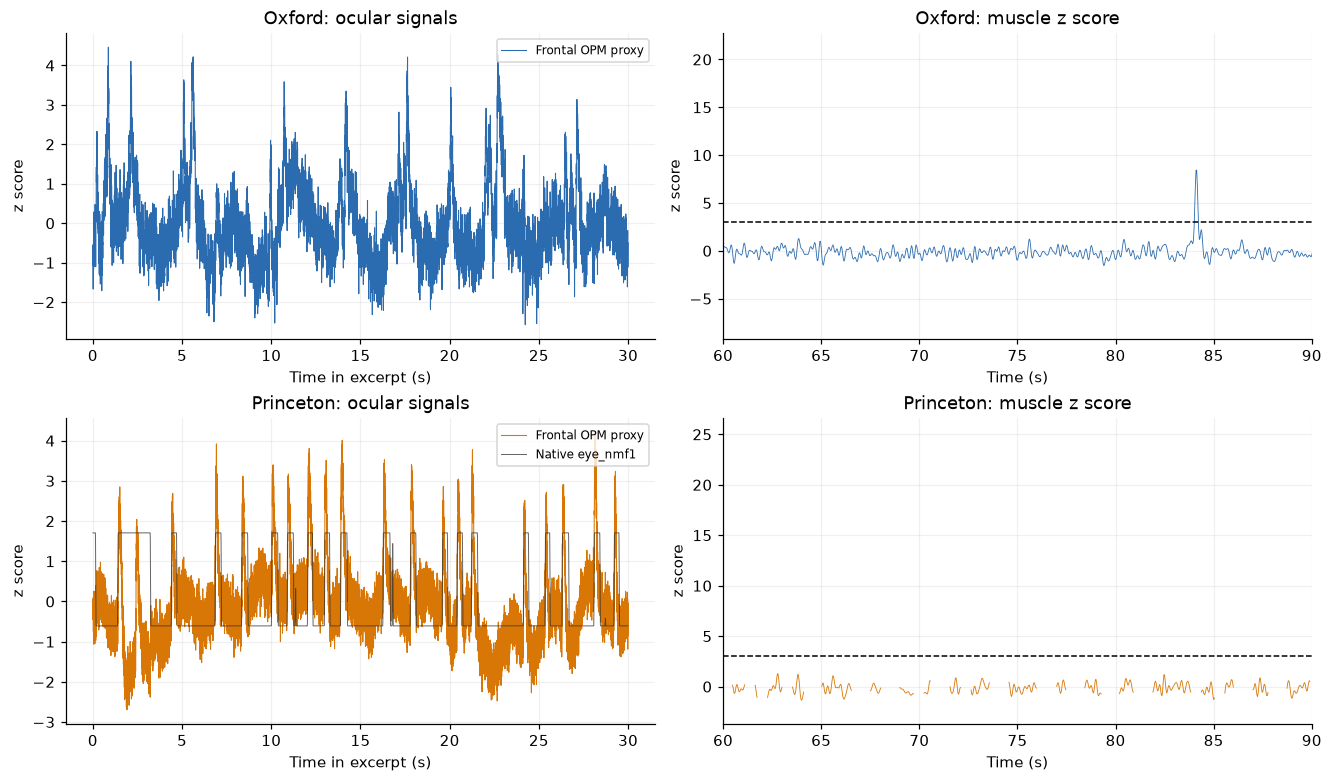

Saved: outputs/flux_oxford_princeton/princeton_sub-038/04_ocular_and_muscle_annotations.png


PosixPath('/Users/harrisonritz/repos/cerca-flux-tutorial/outputs/flux_oxford_princeton/princeton_sub-038/04_ocular_and_muscle_annotations.png')

In [7]:
def find_by_prefix(raw, prefix):
    matches = [
        ch for ch in raw.ch_names if ch.split()[0] == prefix and ch.endswith(" Z")
    ]
    if not matches:
        raise RuntimeError(f"No radial {prefix} channel in {raw.ch_names[:5]}...")
    return matches[0]


def add_frontal_surrogate(raw):
    left, right = find_by_prefix(raw, "F9"), find_by_prefix(raw, "F10")
    signal = raw.get_data(picks=[left])[0] - raw.get_data(picks=[right])[0]
    info = mne.create_info(["EOG_frontal_OPM"], raw.info["sfreq"], ["eog"])
    proxy = mne.io.RawArray(
        signal[np.newaxis], info, first_samp=raw.first_samp, verbose="ERROR"
    )
    raw.add_channels([proxy], force_update_info=True)
    return "EOG_frontal_OPM"


artifact_stats, ocular_comparison, muscle_scores = {}, {}, {}
for name, raw in hfc_raws.items():
    proxy_name = add_frontal_surrogate(raw)
    native_eog = [
        ch
        for ch, typ in zip(raw.ch_names, raw.get_channel_types())
        if typ == "eog" and ch != proxy_name
    ]
    if native_eog:
        stop = int(min(180, raw.times[-1]) * raw.info["sfreq"])
        proxy = raw.get_data(picks=[proxy_name], stop=stop)[0]
        correlations = {}
        for ch in native_eog:
            eog = raw.get_data(picks=[ch], stop=stop)[0]
            correlations[ch] = float(
                np.corrcoef(
                    (proxy - proxy.mean()) / proxy.std(), (eog - eog.mean()) / eog.std()
                )[0, 1]
            )
        best_native = max(correlations, key=lambda x: abs(correlations[x]))
        # Shared mode detects blinks on the same frontal OPM surrogate at both sites.
        eog_name = proxy_name if SHARED_BLINK_DETECTOR else best_native
        ocular_comparison[name] = {
            "proxy": proxy_name,
            "native": best_native,
            "correlations": correlations,
        }
    else:
        eog_name = proxy_name
        ocular_comparison[name] = {
            "proxy": proxy_name,
            "native": None,
            "correlations": {},
        }

    eog_events = mne.preprocessing.find_eog_events(
        raw, ch_name=eog_name, verbose="ERROR"
    )
    if len(eog_events):
        # Annotation onsets use the acquisition time base; event samples include first_samp.
        raw.annotations.append(
            onset=eog_events[:, 0] / raw.info["sfreq"] - 0.25,
            duration=np.full(len(eog_events), 0.5),
            description=["BAD_blink"] * len(eog_events),
        )
    ann_muscle, scores = mne.preprocessing.annotate_muscle_zscore(
        raw,
        threshold=3.0,
        ch_type="mag",
        min_length_good=0.1,
        filter_freq=(110, 130),
        n_jobs=1,
        verbose="ERROR",
    )
    raw.set_annotations(raw.annotations + ann_muscle)
    muscle_scores[name] = scores
    muscle_sec = sum(
        d
        for d, desc in zip(raw.annotations.duration, raw.annotations.description)
        if desc == "BAD_muscle"
    )
    artifact_stats[name] = {
        "blink_count": len(eog_events),
        "blinks_per_min": len(eog_events) / (raw.times[-1] / 60),
        "muscle_seconds": muscle_sec,
        "muscle_percent": 100 * muscle_sec / raw.times[-1],
        "eog_channel": eog_name,
    }

display(pd.DataFrame(artifact_stats).T)
print(
    "Princeton EOG/proxy correlations:", ocular_comparison["Princeton"]["correlations"]
)

fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)
for row, (name, raw) in enumerate(hfc_raws.items()):
    t0, t1 = 60, min(90, raw.times[-1])
    s0, s1 = int(t0 * raw.info["sfreq"]), int(t1 * raw.info["sfreq"])
    proxy = raw.get_data(picks=["EOG_frontal_OPM"], start=s0, stop=s1)[0]
    proxy = (proxy - proxy.mean()) / max(proxy.std(), 1e-30)
    axes[row, 0].plot(
        np.arange(len(proxy)) / raw.info["sfreq"],
        proxy,
        color=COLORS[name],
        lw=0.7,
        label="Frontal OPM proxy",
    )
    native = ocular_comparison[name]["native"]
    if native:
        eog = raw.get_data(picks=[native], start=s0, stop=s1)[0]
        eog = (eog - eog.mean()) / max(eog.std(), 1e-30)
        axes[row, 0].plot(
            np.arange(len(eog)) / raw.info["sfreq"],
            eog,
            color="0.2",
            lw=0.65,
            alpha=0.75,
            label=f"Native {native}",
        )
    axes[row, 0].set(
        title=f"{name}: ocular signals", xlabel="Time in excerpt (s)", ylabel="z score"
    )
    axes[row, 0].legend(loc="upper right", fontsize=8)
    scores = muscle_scores[name]
    st = np.arange(len(scores)) / raw.info["sfreq"]
    axes[row, 1].plot(st[::10], scores[::10], color=COLORS[name], lw=0.55)
    axes[row, 1].axhline(3, color="k", ls="--", lw=1)
    axes[row, 1].set(
        xlim=(t0, min(t1, st[-1])),
        title=f"{name}: muscle z score",
        xlabel="Time (s)",
        ylabel="z score",
    )
save_show(fig, "04_ocular_and_muscle_annotations")

## 7. ICA for attenuating artefacts

FastICA is fit to 3-30 Hz copies resampled to 250 Hz, as recommended by OPM-FLUX, then applied to the full 0-150 Hz comparison data. Components correlated with the chosen ocular channel are selected automatically; at most three are removed to avoid aggressive denoising. The retained component scores and exclusions are reported rather than hidden.

Oxford: 48 components; excluded [np.int64(13), np.int64(5), np.int64(4)]
Princeton: 54 components; excluded [np.int64(1)]


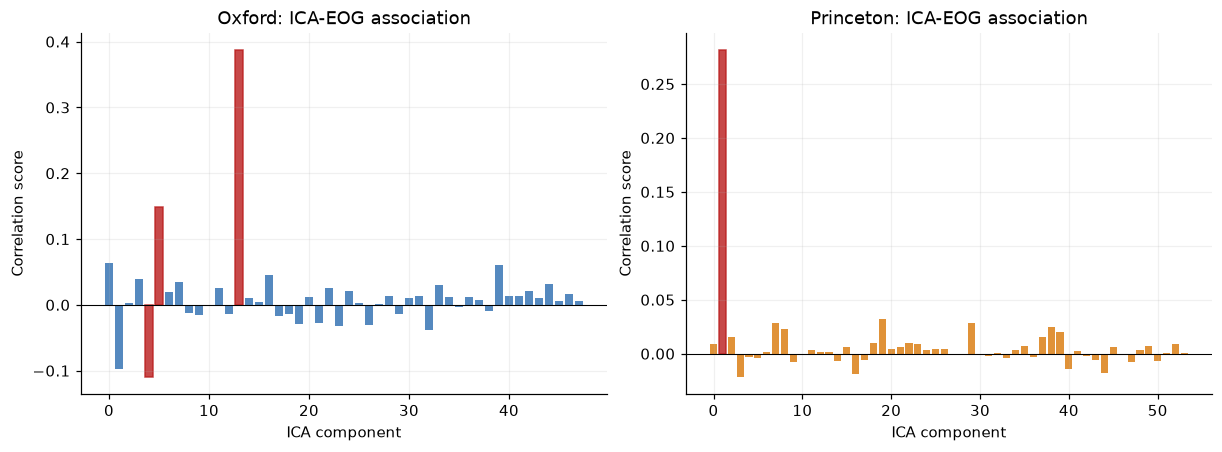

Saved: outputs/flux_oxford_princeton/princeton_sub-038/05_ica_component_selection.png


PosixPath('/Users/harrisonritz/repos/cerca-flux-tutorial/outputs/flux_oxford_princeton/princeton_sub-038/05_ica_component_selection.png')

In [8]:
from mne.preprocessing import ICA

ica_results, clean_raws = {}, {}
for name, raw in hfc_raws.items():
    if not RUN_ICA:
        clean_raws[name] = raw.copy()
        ica_results[name] = {"n_components": 0, "excluded": [], "scores": np.array([])}
        continue
    fit_raw = raw.copy().filter(3, 30, picks="mag", verbose="ERROR")
    fit_raw.resample(ICA_SFREQ, verbose="ERROR")
    ica = ICA(
        method="fastica",
        random_state=RANDOM_STATE,
        n_components=0.99,
        max_iter=500,
        verbose="ERROR",
    )
    ica.fit(fit_raw, picks="mag", reject_by_annotation=True, verbose="ERROR")
    eog_name = artifact_stats[name]["eog_channel"]
    inds, scores = ica.find_bads_eog(
        fit_raw, ch_name=eog_name, threshold=3.0, verbose="ERROR"
    )
    inds = list(inds[:3])
    ica.exclude = inds
    clean = raw.copy()
    ica.apply(clean, verbose="ERROR")
    clean_raws[name] = clean
    ica_results[name] = {
        "ica": ica,
        "n_components": ica.n_components_,
        "excluded": inds,
        "scores": np.asarray(scores),
    }
    print(f"{name}: {ica.n_components_} components; excluded {inds}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for ax, (name, result) in zip(axes, ica_results.items()):
    scores = result["scores"]
    if len(scores):
        bars = ax.bar(np.arange(len(scores)), scores, color=COLORS[name], alpha=0.8)
        for idx in result["excluded"]:
            bars[idx].set_color("#B91C1C")
    ax.axhline(0, color="k", lw=0.7)
    ax.set(
        title=f"{name}: ICA-EOG association",
        xlabel="ICA component",
        ylabel="Correlation score",
    )
save_show(fig, "05_ica_component_selection")

## 8. Extracting trials for specific conditions

The ICA-cleaned continuous data are filtered once (0.1-45 Hz) before epoching to avoid edge artefacts. Response epochs span -1.0 to 1.2 s. Annotated muscle/blink periods and epochs exceeding 50 pT peak-to-peak are rejected. The supplied cue-locked Oxford tutorial uses 10 pT; inspection of these response-locked epochs showed that this removed nearly every Oxford button response, so the same documented 50 pT threshold is used at both sites.

The main comparison pools `resp_T` and `resp_L` for Oxford and selects only `response/right` for Princeton. These `response_epochs` feed every ERF, TFR, LCMV, and DICS analysis. A separately named `mvpa_epochs` object is the **only** place that retains the two-class labels (`resp_T` vs `resp_L`; `response/right` vs `response/left`). The resulting MVPA curves are independent within-dataset QC analyses, not a shared experimental contrast.


In [9]:
response_epochs, mvpa_epochs, epoch_stats = {}, {}, {}
filtered_raws = {}
for name, raw in clean_raws.items():
    continuous = raw.copy().filter(0.1, 45, picks="mag", verbose="ERROR")
    filtered_raws[name] = continuous
    event_times, event_codes, event_id = decoded_events[name]
    events = np.column_stack(
        [
            np.rint(event_times * continuous.info["sfreq"]).astype(int)
            + continuous.first_samp,
            np.zeros(len(event_times), dtype=int),
            event_codes,
        ]
    )
    if name == "Oxford":
        main_ids = {k: event_id[k] for k in ["resp_T", "resp_L"] if k in event_id}
        class_ids = main_ids
    else:
        main_ids = {"response/right": event_id["response/right"]}
        class_ids = {
            k: event_id[k] for k in ["response/right", "response/left"] if k in event_id
        }
    kwargs = dict(
        tmin=-1.0,
        tmax=1.2,
        baseline=None,
        picks="mag",
        detrend=1,
        reject={"mag": REJECT_MAG},
        reject_by_annotation=True,
        preload=True,
        verbose="ERROR",
    )
    ep_main = mne.Epochs(continuous, events, main_ids, **kwargs)
    ep_main.info.normalize_proj()
    # Two-category epochs are quarantined for the MVPA cell only.
    ep_binary = mne.Epochs(continuous, events, class_ids, **kwargs)
    ep_binary.info.normalize_proj()
    response_epochs[name] = ep_main
    mvpa_epochs[name] = ep_binary
    requested = sum(np.isin(events[:, 2], list(main_ids.values())))
    # Drop-log reasons: bad annotations (BAD_blink/BAD_muscle) or channels over REJECT_MAG.
    dropped = [log for log in ep_main.drop_log if log and log != ("IGNORED",)]
    is_blink = ["BAD_blink" in log for log in dropped]
    is_muscle = ["BAD_muscle" in log for log in dropped]
    is_amplitude = [any(ch in ep_main.ch_names for ch in log) for log in dropped]
    epoch_stats[name] = {
        "requested": int(requested),
        "retained": len(ep_main),
        "rejected_percent": 100 * (1 - len(ep_main) / max(requested, 1)),
        "dropped_blink": sum(is_blink),
        "dropped_muscle": sum(is_muscle),
        "dropped_amplitude": sum(is_amplitude),
        "dropped_other": sum(
            not any(flags) for flags in zip(is_blink, is_muscle, is_amplitude)
        ),
        "class_counts": {k: len(ep_binary[k]) for k in class_ids},
    }
display(pd.DataFrame(epoch_stats).T)

,requested,retained,rejected_percent,class_counts
Oxford,314,295,6.050955,"{'resp_T': 157, 'resp_L': 138}"
Princeton,321,149,53.582555,"{'response/right': 149, 'response/left': 141}"


## 9. Response-locked event-related fields and time-domain LCMV

Because corresponding sensor polarities and locations are not identical across participants, the direct sensor comparison uses the polarity-invariant RMS field over six central radial locations (C1-C6). The left panel is in physical units; the right panel divides by the pre-response baseline SD to compare response SNR. Shading is a trial bootstrap SEM approximation computed from epoch-wise central RMS.

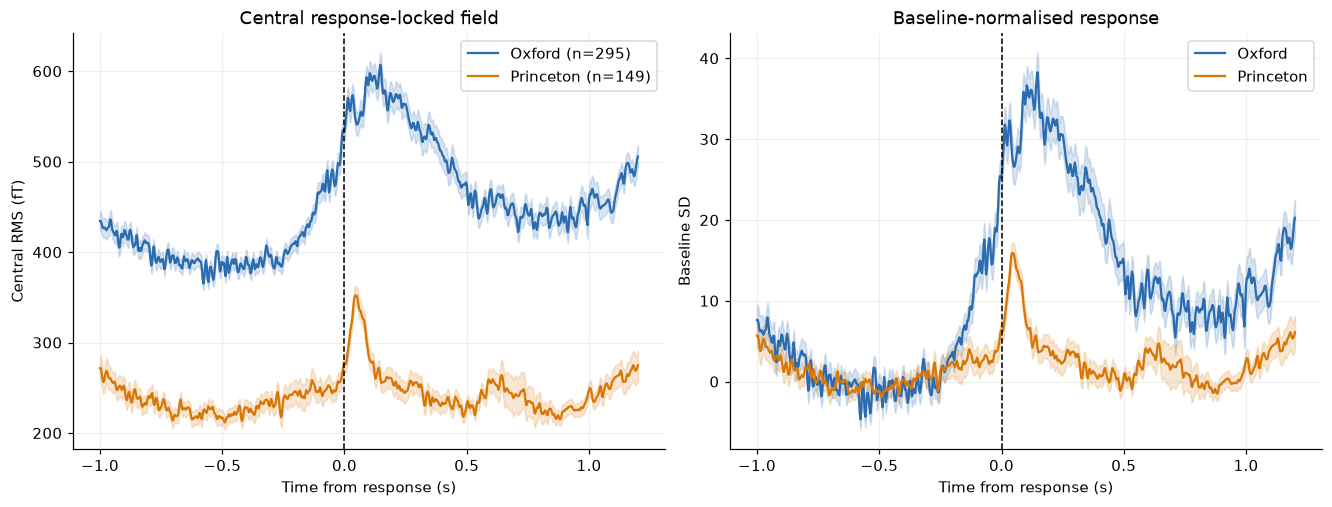

Saved: outputs/flux_oxford_princeton/princeton_sub-038/06_response_locked_erf.png


,baseline_rms_fT,peak_response_rms_fT,peak_response_snr
Oxford,391.42,606.98,38.28
Princeton,226.89,352.12,15.90


In [10]:
CENTRAL = {"C1", "C2", "C3", "C4", "C5", "C6"}


def central_picks(epochs):
    picks = [
        i
        for i, ch in enumerate(epochs.ch_names)
        if ch.split()[0] in CENTRAL and ch.endswith(" Z")
    ]
    if len(picks) < 3:
        raise RuntimeError(f"Only {len(picks)} central channels found")
    return picks


erf_metrics = {}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for name, epochs in response_epochs.items():
    picks = central_picks(epochs)
    x = epochs.get_data(picks=picks) * 1e15
    trial_rms = np.sqrt(np.mean(x**2, axis=1))
    y = trial_rms.mean(axis=0)
    sem = trial_rms.std(axis=0, ddof=1) / np.sqrt(len(trial_rms))
    b = (epochs.times >= -0.8) & (epochs.times <= -0.6)
    z = (y - y[b].mean()) / max(y[b].std(), 1e-12)
    zsem = sem / max(y[b].std(), 1e-12)
    axes[0].plot(epochs.times, y, color=COLORS[name], label=f"{name} (n={len(epochs)})")
    axes[0].fill_between(epochs.times, y - sem, y + sem, color=COLORS[name], alpha=0.18)
    axes[1].plot(epochs.times, z, color=COLORS[name], label=name)
    axes[1].fill_between(
        epochs.times, z - zsem, z + zsem, color=COLORS[name], alpha=0.18
    )
    active = (epochs.times >= -0.1) & (epochs.times <= 0.3)
    erf_metrics[name] = {
        "baseline_rms_fT": float(y[b].mean()),
        "peak_response_rms_fT": float(y[active].max()),
        "peak_response_snr": float(z[active].max()),
    }
for ax in axes:
    ax.axvline(0, color="k", lw=1, ls="--")
    ax.legend()
    ax.set_xlabel("Time from response (s)")
axes[0].set(title="Central response-locked field", ylabel="Central RMS (fT)")
axes[1].set(title="Baseline-normalised response", ylabel="Baseline SD")
save_show(fig, "06_response_locked_erf")
display(pd.DataFrame(erf_metrics).T.round(2))

## 10. Time-frequency representations of motor beta power

Motor beta (15-30 Hz) is estimated with 500 ms DPSS windows (`n_cycles = frequency / 2`, `time_bandwidth = 2`), matching the slow-frequency FLUX recommendation. Power is averaged over central radial sensors and expressed as percent change from -0.9 to -0.6 s. Negative values around movement indicate beta desynchronisation; later positive values indicate beta rebound.

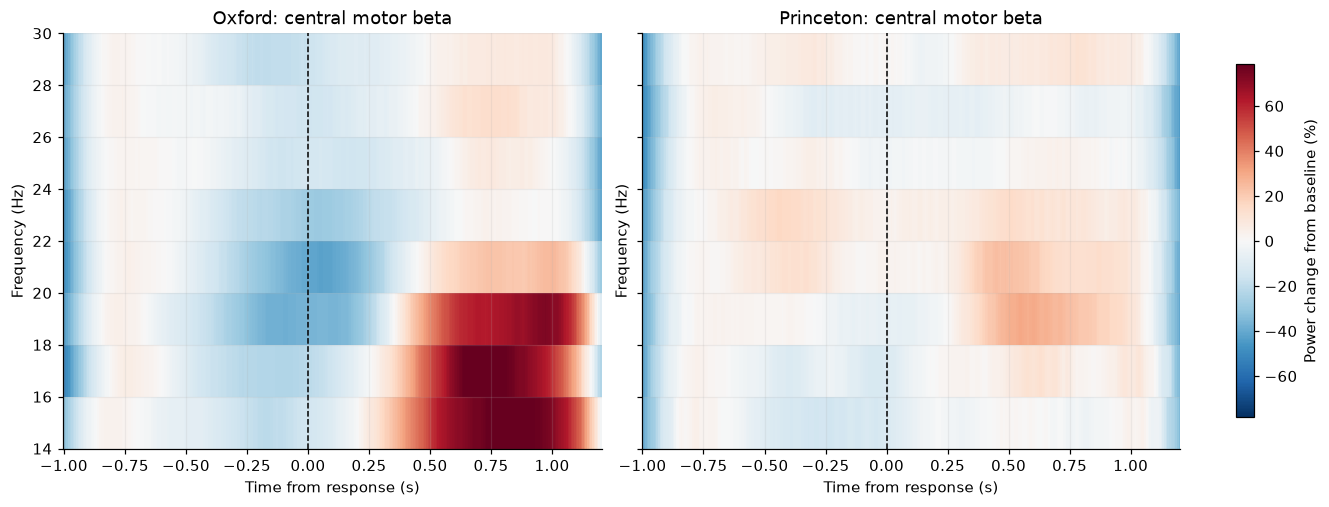

Saved: outputs/flux_oxford_princeton/princeton_sub-038/07_response_locked_motor_beta_tfr.png


,movement_beta_percent,rebound_beta_percent
Oxford,-20.42,26.83
Princeton,-1.94,8.18


In [11]:
freqs = np.arange(15, 31, 2)
tfr_results, beta_metrics = {}, {}
for name, epochs in response_epochs.items():
    picks = central_picks(epochs)
    tfr = epochs.compute_tfr(
        method="multitaper",
        freqs=freqs,
        n_cycles=freqs / 2,
        time_bandwidth=2.0,
        picks=picks,
        average=True,
        return_itc=False,
        decim=2,
        n_jobs=1,
        verbose="ERROR",
    )
    data = tfr.data.mean(axis=0)
    b = (tfr.times >= -0.9) & (tfr.times <= -0.6)
    baseline = data[:, b].mean(axis=1, keepdims=True)
    rel = 100 * (data - baseline) / np.maximum(baseline, np.finfo(float).tiny)
    tfr_results[name] = (tfr.freqs, tfr.times, rel)
    move = (tfr.times >= -0.4) & (tfr.times <= 0.1)
    rebound = (tfr.times >= 0.4) & (tfr.times <= 0.9)
    beta_metrics[name] = {
        "movement_beta_percent": float(rel[:, move].mean()),
        "rebound_beta_percent": float(rel[:, rebound].mean()),
    }

vmax = max(np.nanpercentile(np.abs(v[2]), 98) for v in tfr_results.values())
fig, axes = plt.subplots(
    1, 2, figsize=(12, 4.5), sharex=True, sharey=True, constrained_layout=True
)
for ax, (name, (f, t, rel)) in zip(axes, tfr_results.items()):
    im = ax.pcolormesh(t, f, rel, shading="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.axvline(0, color="k", lw=1, ls="--")
    ax.set(
        title=f"{name}: central motor beta",
        xlabel="Time from response (s)",
        ylabel="Frequency (Hz)",
    )
fig.colorbar(im, ax=axes, label="Power change from baseline (%)", shrink=0.85)
save_show(fig, "07_response_locked_motor_beta_tfr")
display(pd.DataFrame(beta_metrics).T.round(2))

## 11. Classification based on multivariate pattern analysis

This is the notebook's **only category-contrast analysis**, and it is within-dataset QC rather than a cross-dataset semantic comparison. Oxford's `resp_T`/`resp_L` labels are two fingers on the same hand; Princeton's `response/right`/`response/left` labels are different hands. These contrasts are not biologically equivalent and their AUC curves should not be interpreted as the same effect.

Trials are balanced to the same count per class and dataset. A 100 ms sliding-window RBF-SVM uses standardisation, stratified 5-fold cross-validation, and ROC AUC. Above-chance decoding indicates reliable distributed response-category information within that recording; it does not by itself establish cleaner data or comparable motor physiology.


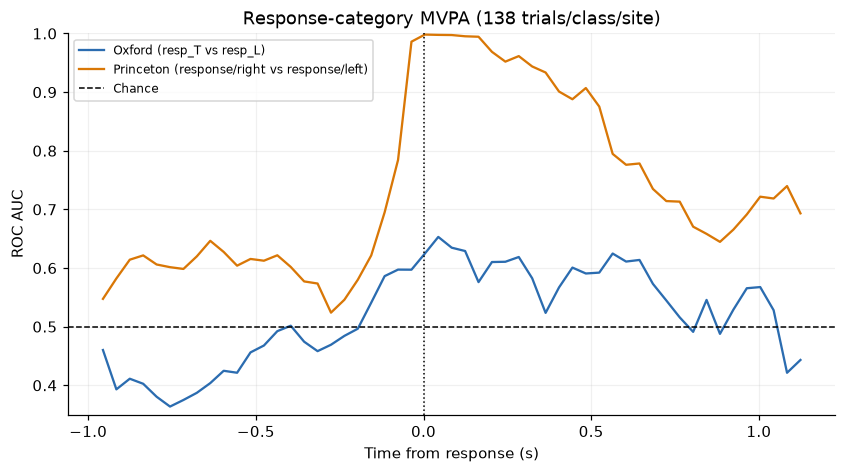

Saved: outputs/flux_oxford_princeton/princeton_sub-038/08_response_mvpa.png


PosixPath('/Users/harrisonritz/repos/cerca-flux-tutorial/outputs/flux_oxford_princeton/princeton_sub-038/08_response_mvpa.png')

In [12]:
def balanced_binary_data(epochs, seed=RANDOM_STATE):
    keys = list(epochs.event_id)
    if len(keys) != 2:
        raise RuntimeError(f"Need two classes, got {keys}")
    rng = np.random.default_rng(seed)
    groups = [epochs[k] for k in keys]
    n = min(len(g) for g in groups)
    # Match both classes without depending on event code ordering.
    arrays = []
    labels = []
    for label, group in enumerate(groups):
        idx = np.sort(rng.choice(len(group), size=n, replace=False))
        arrays.append(group[idx].get_data(picks="mag"))
        labels.extend([label] * n)
    return np.concatenate(arrays), np.asarray(labels), keys


balanced = {name: balanced_binary_data(ep) for name, ep in mvpa_epochs.items()}
global_n = min(x[0].shape[0] // 2 for x in balanced.values())

mvpa_results = {}
for name, (X, y, keys) in balanced.items():
    rng = np.random.default_rng(RANDOM_STATE)
    idx = np.concatenate(
        [rng.choice(np.where(y == c)[0], global_n, replace=False) for c in [0, 1]]
    )
    X, y = X[idx], y[idx]
    # Resample epochs to the FLUX MVPA rate and form 100 ms windows.
    X = resample_poly(X, up=5, down=12, axis=-1)  # 300 Hz -> 125 Hz
    mvpa_times = response_epochs[name].tmin + np.arange(X.shape[-1]) / 125.0
    win = int(round(0.1 * 125))
    starts = np.arange(0, X.shape[-1] - win + 1, 5)
    times = np.array([mvpa_times[s : s + win].mean() for s in starts])
    cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
    clf = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0, gamma="scale"))
    scores = []
    for start in starts:
        Xw = X[:, :, start : start + win].reshape(len(X), -1)
        fold_scores = []
        for train, test in cv.split(Xw, y):
            model = clone(clf).fit(Xw[train], y[train])
            fold_scores.append(
                roc_auc_score(y[test], model.decision_function(Xw[test]))
            )
        scores.append(np.mean(fold_scores))
    mvpa_results[name] = {
        "times": times,
        "scores": np.asarray(scores),
        "classes": keys,
        "n_per_class": global_n,
    }

fig, ax = plt.subplots(figsize=(9, 4.5))
for name, result in mvpa_results.items():
    ax.plot(
        result["times"],
        result["scores"],
        color=COLORS[name],
        label=f"{name} ({result['classes'][0]} vs {result['classes'][1]})",
    )
ax.axhline(0.5, color="k", ls="--", lw=1, label="Chance")
ax.axvline(0, color="k", ls=":", lw=1)
ax.set(
    title=f"Response-category MVPA ({global_n} trials/class/site)",
    xlabel="Time from response (s)",
    ylabel="ROC AUC",
    ylim=(0.35, 1.0),
)
ax.legend(fontsize=8)
save_show(fig, "08_response_mvpa")

## 12. Constructing the forward models

Both datasets include participant-specific structural MRI derivatives and MRI-to-head transforms. Oxford already includes a 5 mm volumetric source space and forward solution. For the selected Princeton folder, this notebook discovers the supplied BEM and transform, constructs the same 5 mm volumetric grid, and computes the forward model. Only retained radial channels are selected from each forward model.

Coregistration is not re-fit automatically: the supplied transforms are treated as experimental metadata and should be visually checked before inferential source analysis. Each reconstruction also contains a FreeSurfer `talairach.xfm`, which is used in the next section to map source coordinates into MNI space.


In [13]:
OX_ANALYSIS = OX_ROOT / "Data/Cerca_Spatt_BIDS/derivatives/analysis/sub-01/ses-01/meg"
OX_FWD = OX_ANALYSIS / "sub-01_ses-01_task-SpAtt_run-01_fwd.fif"
OX_FS_ROOT = OX_ROOT / "Data/Cerca_Spatt_BIDS/derivatives/Freesurfer"
OX_FS_SUBJECT = "T1s"

PR_FS_ROOT = PR_ROOT
PR_FS_SUBJECT = "freesurfer"
PR_BEM_DIR = PR_FS_ROOT / PR_FS_SUBJECT / "bem"


def require_one(paths, description):
    paths = sorted(paths)
    if len(paths) != 1:
        raise RuntimeError(f"Expected one {description}; found {len(paths)}: {paths}")
    return paths[0]


PR_BEM = require_one(PR_BEM_DIR.glob("*-bem-sol.fif"), "Princeton BEM solution")
PR_TRANS = require_one(PR_BEM_DIR.glob("*-trans.fif"), "Princeton MRI/head transform")
PR_T1 = PR_FS_ROOT / PR_FS_SUBJECT / "mri/T1.mgz"

SOURCE_ANATOMY = {
    "Oxford": {"subject": OX_FS_SUBJECT, "subjects_dir": OX_FS_ROOT},
    "Princeton": {"subject": PR_FS_SUBJECT, "subjects_dir": PR_FS_ROOT},
}
for name, anatomy in SOURCE_ANATOMY.items():
    talairach = (
        anatomy["subjects_dir"] / anatomy["subject"] / "mri/transforms/talairach.xfm"
    )
    assert talairach.exists(), f"Missing {name} Talairach transform: {talairach}"

forward_models, forward_summary, source_errors = {}, {}, {}
if RUN_SOURCE_MODELING:
    try:
        forward_models["Oxford"] = mne.read_forward_solution(OX_FWD, verbose="ERROR")
    except Exception as exc:
        source_errors["Oxford forward"] = repr(exc)
    try:
        pr_src = mne.setup_volume_source_space(
            subject=PR_FS_SUBJECT,
            pos=5.0,
            bem=PR_BEM,
            mri=PR_T1,
            subjects_dir=PR_FS_ROOT,
            add_interpolator=False,
            verbose="ERROR",
        )
        pr_info = source_infos["Princeton"].copy()
        forward_models["Princeton"] = mne.make_forward_solution(
            pr_info,
            trans=PR_TRANS,
            src=pr_src,
            bem=PR_BEM,
            meg=True,
            eeg=False,
            mindist=5.0,
            n_jobs=1,
            verbose="ERROR",
        )
    except Exception as exc:
        source_errors["Princeton forward"] = repr(exc)

for name, fwd in list(forward_models.items()):
    include = response_epochs[name].ch_names
    fwd = mne.pick_channels_forward(
        fwd, include=include, ordered=True, copy=True, verbose="ERROR"
    )
    forward_models[name] = fwd
    forward_summary[name] = {
        "channels": len(fwd["info"]["ch_names"]),
        "sources": sum(s["nuse"] for s in fwd["src"]),
        "source_kind": "+".join(s["type"] for s in fwd["src"]),
        "native_coord_frame": mne.transforms._coord_frame_name(
            fwd["src"][0]["coord_frame"]
        ),
        "display_coord_frame": "MNI (Talairach affine)",
    }
display(pd.DataFrame(forward_summary).T)
if source_errors:
    display(source_errors)


,channels,sources,source_kind,native_coord_frame,display_coord_frame
Oxford,60,9786,vol,head,MNI (Talairach affine)
Princeton,64,11312,vol,head,MNI (Talairach affine)


## 13. Source modelling with time-domain LCMV and beta-band DICS

Two matched beamformers are applied to the main response selections (pooled Oxford responses and Princeton `response/right`); **neither uses the T/L or right/left category contrast**:

1. **LCMV** uses one common -0.8 to 0.8 s covariance and 5% regularisation. The time course is whole-grid source RMS, normalised to the -0.8 to -0.6 s baseline. The anatomical map is the per-voxel power change, in dB, between a pre-response baseline (-0.8 to -0.5 s) and a response window (-0.2 to 0.3 s).
2. **DICS** estimates motor beta with one common filter made from movement (-0.4 to 0.1 s) and rebound (0.4 to 0.9 s) CSDs, 5% regularisation, maximum-power orientation, and the temporal contrast `(rebound - movement) / (rebound + movement)`.

Both source estimates are rendered as volumetric overlays on each participant's own T1 MRI so anatomical location and spatial spread are visible. Within each method, both sites use one exploratory threshold—the pooled 95th percentile of the absolute source statistic—and one colour limit—the pooled 99th percentile. This robust, common rule suppresses diffuse low-amplitude estimates without choosing a different threshold for each dataset. It is **not** a statistical significance threshold; confirmatory inference would require an appropriate permutation/null distribution.

For LCMV, the peak is the voxel with the largest response-versus-baseline dB increase. Its anatomical name is sampled from that participant's FreeSurfer `aparc+aseg.mgz`; its coordinate is also transformed through the MRI/head transform and Talairach affine into MNI space. Atlas labels should be treated as approximate at the 5 mm source-grid resolution and visually checked near parcel boundaries.


{'mag': 52}
{'mag': 49}


/Users/harrisonritz/repos/cerca-flux-tutorial/.venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2349: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/harrisonritz/repos/cerca-flux-tutorial/.venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2349: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/harrisonritz/repos/cerca-flux-tutorial/.venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2349: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/harrisonritz/repos/cerca-flux-tutorial/.venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2349: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/harrisonritz/repos/cerca-flux-tutorial/.venv/lib/python3.14/site-packages/numpy/linalg/_

{'mag': 56}
{'mag': 55}


/Users/harrisonritz/repos/cerca-flux-tutorial/.venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2349: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/harrisonritz/repos/cerca-flux-tutorial/.venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2349: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/harrisonritz/repos/cerca-flux-tutorial/.venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2349: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/harrisonritz/repos/cerca-flux-tutorial/.venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2349: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/harrisonritz/repos/cerca-flux-tutorial/.venv/lib/python3.14/site-packages/numpy/linalg/_

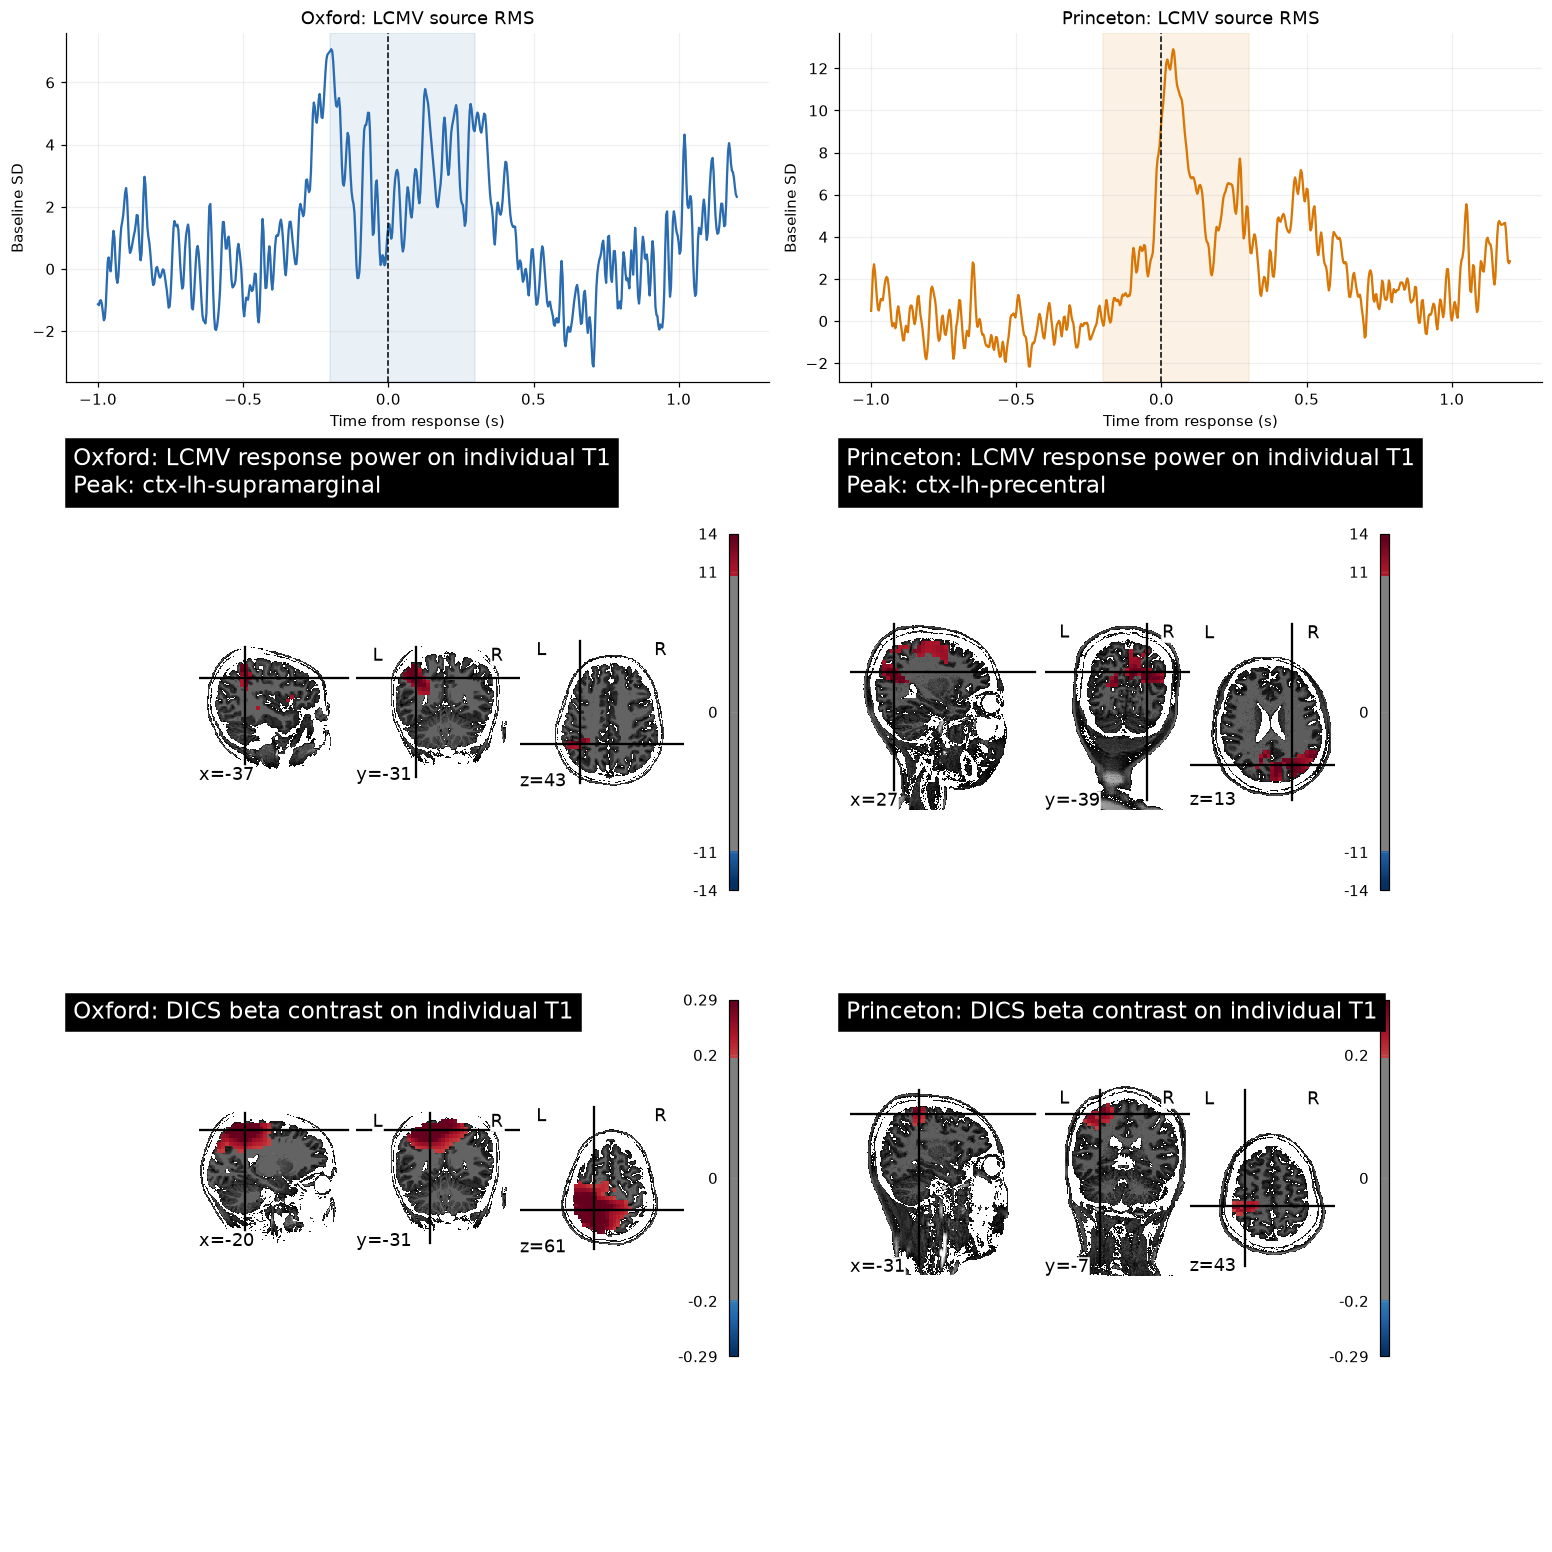

Saved: outputs/flux_oxford_princeton/princeton_sub-038/09_lcmv_and_dics_on_individual_mri.png


,LCMV_peak_dB,FreeSurfer_parcel,parcel_assignment,parcel_distance_mm,atlas_label_id,MNI_x_mm,MNI_y_mm,MNI_z_mm
dataset,,,,,,,,
Oxford,14.35,ctx-lh-supramarginal,nearest cortical parcel,5.0,1031,-46.35,-48.17,52.07
Princeton,18.02,ctx-lh-precentral,exact peak voxel,0.0,1024,-32.78,-14.98,66.34


Common exploratory thresholds — LCMV: |dB| >= 10.85, saturation +/-13.59; DICS: |contrast| >= 0.196, saturation +/-0.285


In [14]:
from mne.beamformer import make_lcmv, apply_lcmv, make_dics, apply_dics_csd
from mne.time_frequency import csd_multitaper
from nilearn import image as nli, plotting as nlp
import nibabel as nib
from nibabel.processing import resample_from_to
from scipy.ndimage import distance_transform_edt

source_results = {}
for name, epochs in response_epochs.items():
    if name not in forward_models:
        continue
    try:
        fwd = forward_models[name]
        rank = mne.compute_rank(epochs, rank="info", verbose="ERROR")
        print(rank)
        rank = mne.compute_rank(epochs, tol=1e-5, tol_kind="relative", proj=True)
        print(rank)
        data_cov = mne.compute_covariance(
            epochs, tmin=-0.8, tmax=0.8, method="shrunk", rank=rank, verbose="ERROR"
        )
        lcmv = make_lcmv(
            epochs.info,
            fwd,
            data_cov,
            reg=0.05,
            noise_cov=None,
            pick_ori="max-power",
            weight_norm="unit-noise-gain-invariant",
            reduce_rank=True,
            depth=None,
            rank=rank,
            verbose="ERROR",
        )
        stc_lcmv = apply_lcmv(epochs.average(), lcmv, verbose="ERROR")

        csd_move = csd_multitaper(
            epochs,
            fmin=15,
            fmax=30,
            tmin=-0.4,
            tmax=0.1,
            bandwidth=4,
            low_bias=True,
            n_jobs=1,
            verbose="ERROR",
        ).mean(15, 30)
        csd_rebound = csd_multitaper(
            epochs,
            fmin=15,
            fmax=30,
            tmin=0.4,
            tmax=0.9,
            bandwidth=4,
            low_bias=True,
            n_jobs=1,
            verbose="ERROR",
        ).mean(15, 30)
        csd_common = csd_move.copy()
        csd_common._data = (csd_move._data + csd_rebound._data) / 2
        dics = make_dics(
            epochs.info,
            fwd,
            csd_common,
            reg=0.05,
            noise_csd=None,
            pick_ori="max-power",
            reduce_rank=True,
            real_filter=True,
            depth=None,
            rank=rank,
            verbose="ERROR",
        )
        stc_move, _ = apply_dics_csd(csd_move, dics, verbose="ERROR")
        stc_rebound, _ = apply_dics_csd(csd_rebound, dics, verbose="ERROR")
        eps = np.finfo(float).eps * np.nanmax(stc_move.data + stc_rebound.data)
        stc_beta = (stc_rebound - stc_move) / (stc_rebound + stc_move + eps)
        source_results[name] = {
            "lcmv": stc_lcmv,
            "dics": stc_beta,
            "fwd": fwd,
            "rank": rank,
            "data_cov": data_cov,
            "csd_move": csd_move,
            "csd_rebound": csd_rebound,
            "csd_common": csd_common,
        }
    except Exception as exc:
        source_errors[f"{name} beamformer"] = repr(exc)


def volume_coords_mni(stc, fwd, anatomy):
    vertices = np.asarray(stc.vertices[0], int)
    head_coordinates_m = fwd["src"][0]["rr"][vertices]
    return mne.head_to_mni(
        head_coordinates_m,
        subject=anatomy["subject"],
        mri_head_t=fwd["mri_head_t"],
        subjects_dir=anatomy["subjects_dir"],
        verbose="ERROR",
    )


source_peaks = []
if source_results:
    atlas_ids, _ = mne.read_freesurfer_lut()
    atlas_names = {label_id: label for label, label_id in atlas_ids.items()}

    for name, result in source_results.items():
        stc = result["lcmv"]
        baseline = (stc.times >= -0.8) & (stc.times <= -0.5)
        response = (stc.times >= -0.2) & (stc.times <= 0.3)
        baseline_power = np.mean(np.abs(stc.data[:, baseline]) ** 2, axis=1)
        response_power = np.mean(np.abs(stc.data[:, response]) ** 2, axis=1)
        floor = np.finfo(float).eps * max(
            float(np.nanmax(baseline_power)), np.finfo(float).tiny
        )
        lcmv_db = 10 * np.log10(
            np.maximum(response_power, floor) / np.maximum(baseline_power, floor)
        )
        result["lcmv_response_db"] = lcmv_db
        result["lcmv_map"] = mne.VolSourceEstimate(
            lcmv_db[:, np.newaxis],
            vertices=stc.vertices,
            tmin=0.0,
            tstep=1.0,
            subject=stc.subject,
        )
        result["lcmv_native_img"] = nli.index_img(
            result["lcmv_map"].as_volume(
                result["fwd"]["src"], dest="mri", mri_resolution=False
            ),
            0,
        )
        result["dics_native_img"] = nli.index_img(
            result["dics"].as_volume(
                result["fwd"]["src"], dest="mri", mri_resolution=False
            ),
            0,
        )

        anatomy = SOURCE_ANATOMY[name]
        result["mni_mm"] = volume_coords_mni(result["dics"], result["fwd"], anatomy)
        peak = int(np.nanargmax(lcmv_db))

        aseg_path = anatomy["subjects_dir"] / anatomy["subject"] / "mri/aparc+aseg.mgz"
        aseg = nib.load(str(aseg_path))
        atlas_on_source_grid = resample_from_to(
            aseg, result["lcmv_native_img"], order=0
        ).get_fdata()
        map_data = result["lcmv_native_img"].get_fdata()
        peak_voxel = np.unravel_index(np.nanargmax(map_data), map_data.shape)
        label_id = int(np.rint(atlas_on_source_grid[peak_voxel]))
        parcel = atlas_names.get(label_id, f"Unknown label {label_id}")
        parcel_assignment = "exact peak voxel"
        parcel_distance_mm = 0.0
        if label_id == 0:
            # A 5 mm grid point can fall just outside the thin cortical ribbon.
            # In that case, report the nearest aparc cortical parcel and distance.
            cortical_ids = np.array(
                [
                    label_id
                    for label, label_id in atlas_ids.items()
                    if label.startswith("ctx-")
                ],
                dtype=int,
            )
            cortical_mask = np.isin(
                np.rint(atlas_on_source_grid).astype(int), cortical_ids
            )
            voxel_sizes_mm = nib.affines.voxel_sizes(result["lcmv_native_img"].affine)
            distances, nearest = distance_transform_edt(
                ~cortical_mask,
                sampling=voxel_sizes_mm,
                return_indices=True,
            )
            nearest_voxel = tuple(
                nearest[:, peak_voxel[0], peak_voxel[1], peak_voxel[2]]
            )
            label_id = int(np.rint(atlas_on_source_grid[nearest_voxel]))
            parcel = atlas_names.get(label_id, f"Unknown label {label_id}")
            parcel_assignment = "nearest cortical parcel"
            parcel_distance_mm = float(distances[peak_voxel])

        source_peaks.append(
            {
                "dataset": name,
                "LCMV_peak_dB": float(lcmv_db[peak]),
                "FreeSurfer_parcel": parcel,
                "parcel_assignment": parcel_assignment,
                "parcel_distance_mm": parcel_distance_mm,
                "atlas_label_id": label_id,
                "MNI_x_mm": float(result["mni_mm"][peak, 0]),
                "MNI_y_mm": float(result["mni_mm"][peak, 1]),
                "MNI_z_mm": float(result["mni_mm"][peak, 2]),
            }
        )

    pooled_lcmv = np.concatenate(
        [np.abs(result["lcmv_response_db"]) for result in source_results.values()]
    )
    pooled_dics = np.concatenate(
        [
            np.abs(np.real(result["dics"].data[:, 0]))
            for result in source_results.values()
        ]
    )
    lcmv_threshold = float(np.nanpercentile(pooled_lcmv, 95))
    lcmv_vmax = float(np.nanpercentile(pooled_lcmv, 99))
    dics_threshold = float(np.nanpercentile(pooled_dics, 95))
    dics_vmax = float(np.nanpercentile(pooled_dics, 99))
    lcmv_vmax = max(lcmv_vmax, lcmv_threshold + np.finfo(float).eps)
    dics_vmax = max(dics_vmax, dics_threshold + np.finfo(float).eps)

    fig, axes = plt.subplots(
        3,
        2,
        figsize=(14, 14),
        gridspec_kw={"height_ratios": [0.8, 1.25, 1.25]},
        constrained_layout=True,
    )
    for col, (name, result) in enumerate(source_results.items()):
        stc = result["lcmv"]
        gfp = np.sqrt(np.mean(np.abs(stc.data) ** 2, axis=0))
        b = (stc.times >= -0.8) & (stc.times <= -0.6)
        z = (gfp - gfp[b].mean()) / max(gfp[b].std(), np.finfo(float).eps)
        axes[0, col].plot(stc.times, z, color=COLORS[name])
        axes[0, col].axvspan(-0.2, 0.3, color=COLORS[name], alpha=0.10)
        axes[0, col].axvline(0, color="k", ls="--", lw=1)
        axes[0, col].set(
            title=f"{name}: LCMV source RMS",
            xlabel="Time from response (s)",
            ylabel="Baseline SD",
        )

        anatomy = SOURCE_ANATOMY[name]
        t1 = anatomy["subjects_dir"] / anatomy["subject"] / "mri/T1.mgz"
        peak_row = next(row for row in source_peaks if row["dataset"] == name)

        nlp.plot_stat_map(
            result["lcmv_native_img"],
            bg_img=str(t1),
            display_mode="ortho",
            cut_coords=None,
            threshold=lcmv_threshold,
            vmax=lcmv_vmax,
            symmetric_cbar=True,
            cmap="RdBu_r",
            colorbar=True,
            annotate=True,
            draw_cross=True,
            black_bg=False,
            dim=-0.25,
            figure=fig,
            axes=axes[1, col],
            title=(
                f"{name}: LCMV response power on individual T1\n"
                f"Peak: {peak_row['FreeSurfer_parcel']}"
            ),
        )

        nlp.plot_stat_map(
            result["dics_native_img"],
            bg_img=str(t1),
            display_mode="ortho",
            cut_coords=None,
            threshold=dics_threshold,
            vmax=dics_vmax,
            symmetric_cbar=True,
            cmap="RdBu_r",
            colorbar=True,
            annotate=True,
            draw_cross=True,
            black_bg=False,
            dim=-0.25,
            figure=fig,
            axes=axes[2, col],
            title=f"{name}: DICS beta contrast on individual T1",
        )
    save_show(fig, "09_lcmv_and_dics_on_individual_mri")
    peak_table = pd.DataFrame(source_peaks).set_index("dataset")
    display(peak_table.round(2))
    print(
        "Common exploratory thresholds — "
        f"LCMV: |dB| >= {lcmv_threshold:.2f}, saturation +/-{lcmv_vmax:.2f}; "
        f"DICS: |contrast| >= {dics_threshold:.3f}, saturation +/-{dics_vmax:.3f}"
    )
else:
    print("Source analysis did not run. Errors:", source_errors)

if source_errors:
    display(source_errors)


## 14. Surface source reconstruction with oct6 spacing

As a complementary view of cortical spread, the same LCMV and DICS analyses are recomputed with participant-specific FreeSurfer surface source spaces at **oct6 spacing** (approximately 4,098 vertices per hemisphere). The surface forward models use the same retained radial sensors, BEMs, MRI/head transforms, covariance/CSD estimates, regularisation, orientation choice, and response selections as the volume analysis.

The maps are shown on inflated left and right lateral surfaces. LCMV again represents response-versus-baseline power change in dB; DICS represents beta rebound versus movement. Each method uses a pooled 95th-percentile absolute threshold and pooled 99th-percentile colour saturation across the two datasets. These are exploratory display thresholds, not statistical significance thresholds.


,surface_LCMV_peak_dB,aparc_parcel,surface_vertex
dataset,,,
Oxford,14.20,supramarginal-lh,43887
Princeton,17.98,precentral-lh,53533


### Oxford: LCMV response power (dB) — oct6 surface

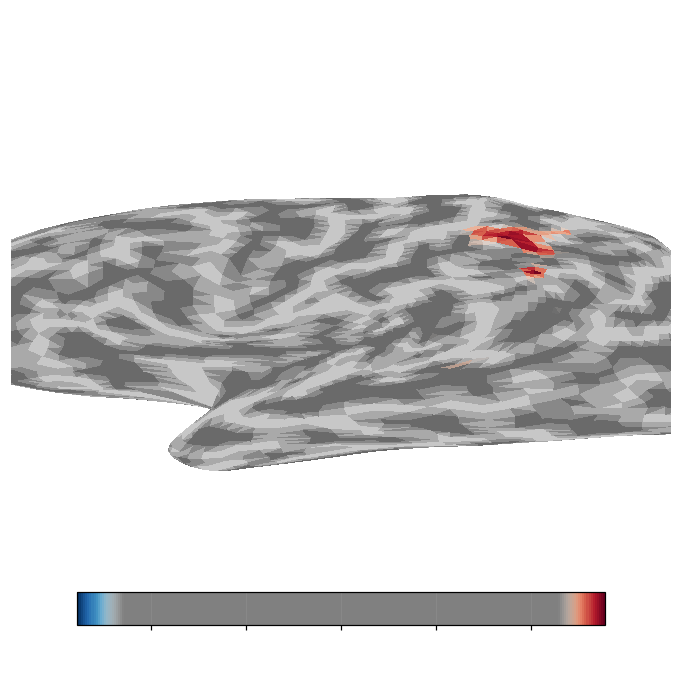

Saved: outputs/flux_oxford_princeton/princeton_sub-038/10_oxford_lcmv_lh_oct6.png


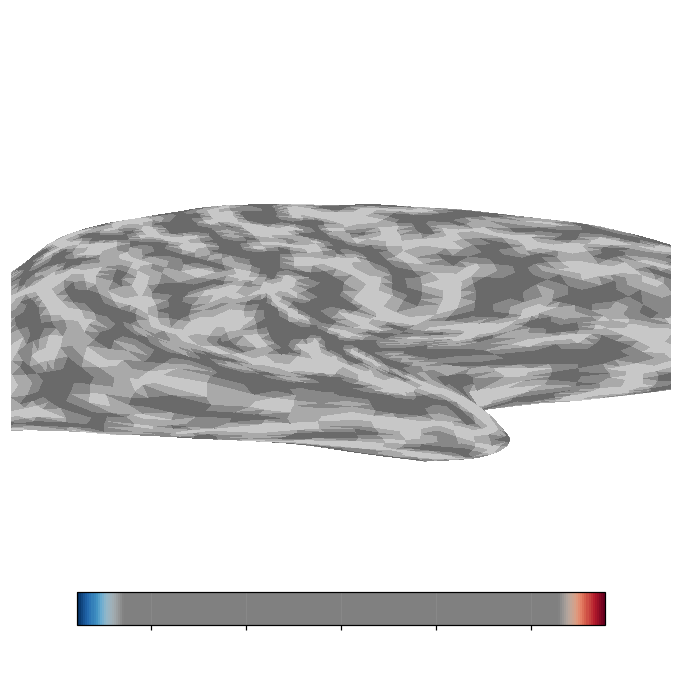

Saved: outputs/flux_oxford_princeton/princeton_sub-038/10_oxford_lcmv_rh_oct6.png


### Oxford: DICS beta rebound - movement — oct6 surface

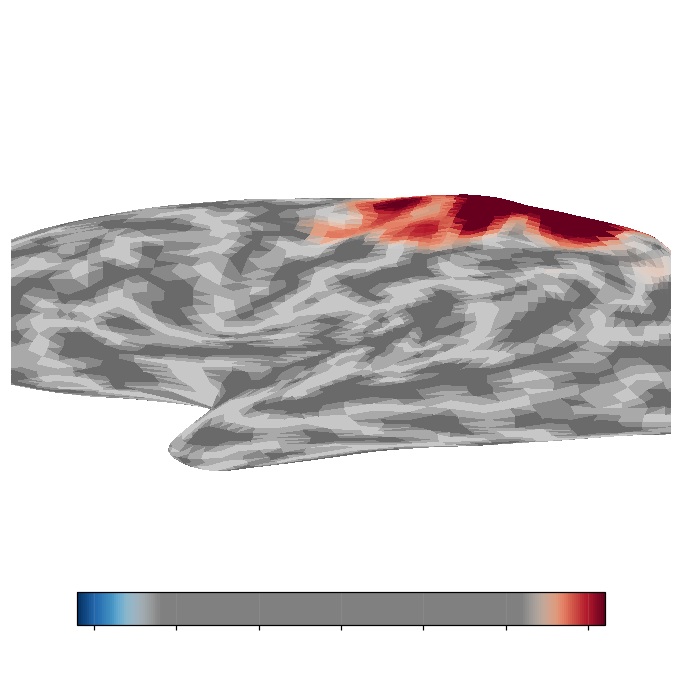

Saved: outputs/flux_oxford_princeton/princeton_sub-038/10_oxford_dics_lh_oct6.png


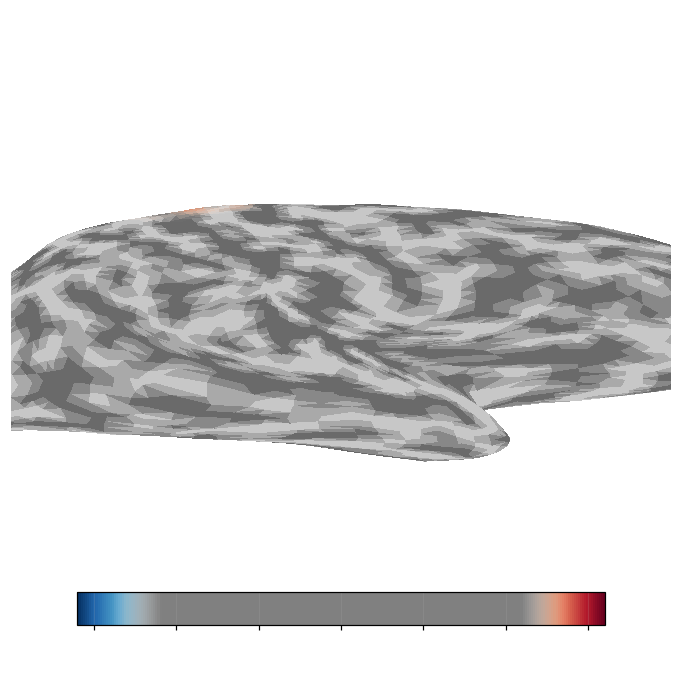

Saved: outputs/flux_oxford_princeton/princeton_sub-038/10_oxford_dics_rh_oct6.png


### Princeton: LCMV response power (dB) — oct6 surface

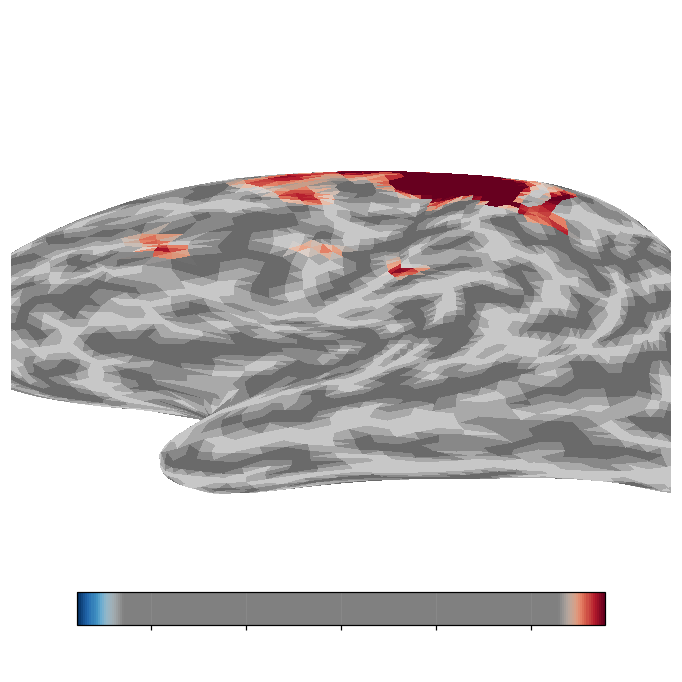

Saved: outputs/flux_oxford_princeton/princeton_sub-038/10_princeton_lcmv_lh_oct6.png


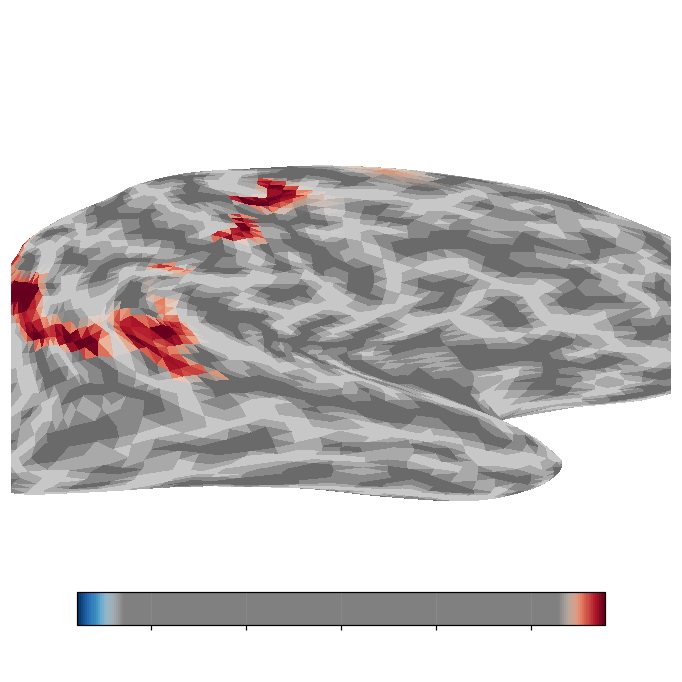

Saved: outputs/flux_oxford_princeton/princeton_sub-038/10_princeton_lcmv_rh_oct6.png


### Princeton: DICS beta rebound - movement — oct6 surface

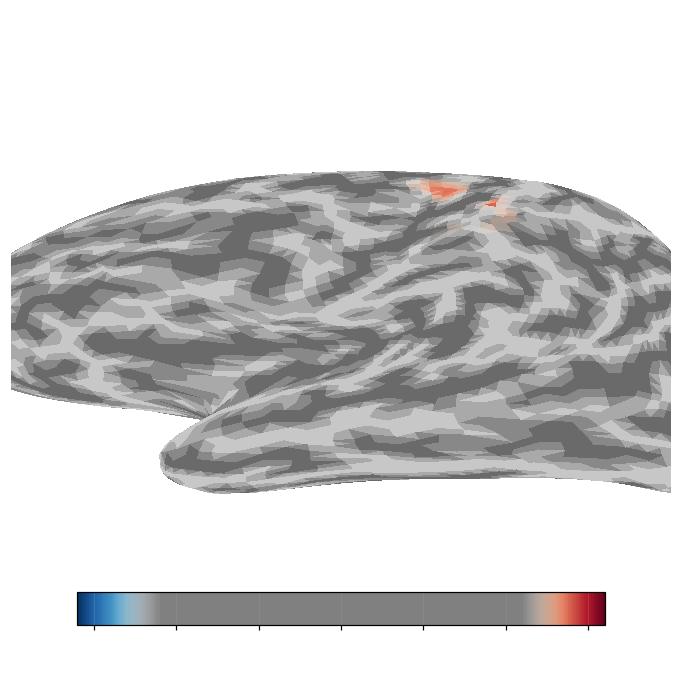

Saved: outputs/flux_oxford_princeton/princeton_sub-038/10_princeton_dics_lh_oct6.png


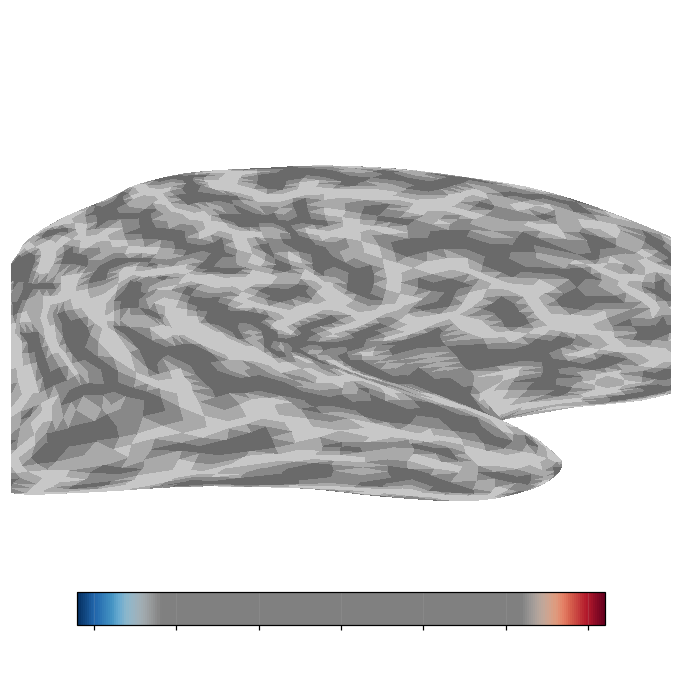

Saved: outputs/flux_oxford_princeton/princeton_sub-038/10_princeton_dics_rh_oct6.png
Common exploratory surface thresholds — LCMV: |dB| >= 11.49, saturation +/-13.93; DICS: |contrast| >= 0.219, saturation +/-0.321


In [15]:
OX_BEM = OX_ANALYSIS / "sub-01_ses-01_task-SpAtt_run-01_bem-sol.fif"
SURFACE_BEMS = {"Oxford": OX_BEM, "Princeton": PR_BEM}

surface_results, surface_errors = {}, {}
for name, epochs in response_epochs.items():
    if name not in source_results:
        continue
    try:
        anatomy = SOURCE_ANATOMY[name]
        src_surf = mne.setup_source_space(
            subject=anatomy["subject"],
            spacing="oct6",
            surface="white",
            subjects_dir=anatomy["subjects_dir"],
            add_dist=False,
            n_jobs=1,
            verbose="ERROR",
        )
        fwd_surf = mne.make_forward_solution(
            epochs.info,
            trans=forward_models[name]["mri_head_t"],
            src=src_surf,
            bem=SURFACE_BEMS[name],
            meg=True,
            eeg=False,
            mindist=5.0,
            n_jobs=1,
            verbose="ERROR",
        )
        inputs = source_results[name]
        lcmv_surf = make_lcmv(
            epochs.info,
            fwd_surf,
            inputs["data_cov"],
            reg=0.05,
            noise_cov=None,
            pick_ori="max-power",
            weight_norm="unit-noise-gain-invariant",
            reduce_rank=True,
            depth=None,
            rank=inputs["rank"],
            verbose="ERROR",
        )
        stc_lcmv_surf = apply_lcmv(epochs.average(), lcmv_surf, verbose="ERROR")

        dics_surf = make_dics(
            epochs.info,
            fwd_surf,
            inputs["csd_common"],
            reg=0.05,
            noise_csd=None,
            pick_ori="max-power",
            reduce_rank=True,
            real_filter=True,
            depth=None,
            rank=inputs["rank"],
            verbose="ERROR",
        )
        stc_move_surf, _ = apply_dics_csd(
            inputs["csd_move"], dics_surf, verbose="ERROR"
        )
        stc_rebound_surf, _ = apply_dics_csd(
            inputs["csd_rebound"], dics_surf, verbose="ERROR"
        )
        eps = np.finfo(float).eps * np.nanmax(
            stc_move_surf.data + stc_rebound_surf.data
        )
        stc_dics_surf = (stc_rebound_surf - stc_move_surf) / (
            stc_rebound_surf + stc_move_surf + eps
        )

        baseline = (stc_lcmv_surf.times >= -0.8) & (stc_lcmv_surf.times <= -0.5)
        response = (stc_lcmv_surf.times >= -0.2) & (stc_lcmv_surf.times <= 0.3)
        baseline_power = np.mean(np.abs(stc_lcmv_surf.data[:, baseline]) ** 2, axis=1)
        response_power = np.mean(np.abs(stc_lcmv_surf.data[:, response]) ** 2, axis=1)
        floor = np.finfo(float).eps * max(
            float(np.nanmax(baseline_power)), np.finfo(float).tiny
        )
        lcmv_db = 10 * np.log10(
            np.maximum(response_power, floor) / np.maximum(baseline_power, floor)
        )
        stc_lcmv_map = mne.SourceEstimate(
            lcmv_db[:, np.newaxis],
            vertices=stc_lcmv_surf.vertices,
            tmin=0.0,
            tstep=1.0,
            subject=anatomy["subject"],
        )
        surface_results[name] = {
            "src": src_surf,
            "fwd": fwd_surf,
            "lcmv": stc_lcmv_map,
            "dics": stc_dics_surf,
        }
    except Exception as exc:
        surface_errors[name] = repr(exc)


def surface_peak_label(stc, anatomy):
    peak = int(np.nanargmax(stc.data[:, 0]))
    n_lh = len(stc.vertices[0])
    hemi = "lh" if peak < n_lh else "rh"
    local_index = peak if hemi == "lh" else peak - n_lh
    vertex = int(stc.vertices[0 if hemi == "lh" else 1][local_index])
    labels = mne.read_labels_from_annot(
        anatomy["subject"],
        parc="aparc",
        hemi=hemi,
        subjects_dir=anatomy["subjects_dir"],
        verbose="ERROR",
    )
    matches = [label.name for label in labels if vertex in label.vertices]
    return matches[0] if matches else f"unlabeled-{hemi}", vertex


if surface_results:
    pooled_surface_lcmv = np.concatenate(
        [np.abs(result["lcmv"].data[:, 0]) for result in surface_results.values()]
    )
    pooled_surface_dics = np.concatenate(
        [
            np.abs(np.real(result["dics"].data[:, 0]))
            for result in surface_results.values()
        ]
    )
    surf_lcmv_threshold = float(np.nanpercentile(pooled_surface_lcmv, 95))
    surf_lcmv_vmax = float(np.nanpercentile(pooled_surface_lcmv, 99))
    surf_dics_threshold = float(np.nanpercentile(pooled_surface_dics, 95))
    surf_dics_vmax = float(np.nanpercentile(pooled_surface_dics, 99))
    surf_lcmv_vmax = max(surf_lcmv_vmax, surf_lcmv_threshold + np.finfo(float).eps)
    surf_dics_vmax = max(surf_dics_vmax, surf_dics_threshold + np.finfo(float).eps)
    surface_clims = {
        "lcmv": dict(
            kind="value",
            pos_lims=[
                surf_lcmv_threshold,
                (surf_lcmv_threshold + surf_lcmv_vmax) / 2,
                surf_lcmv_vmax,
            ],
        ),
        "dics": dict(
            kind="value",
            pos_lims=[
                surf_dics_threshold,
                (surf_dics_threshold + surf_dics_vmax) / 2,
                surf_dics_vmax,
            ],
        ),
    }

    surface_peak_rows = []
    for name, result in surface_results.items():
        parcel, vertex = surface_peak_label(result["lcmv"], SOURCE_ANATOMY[name])
        surface_peak_rows.append(
            {
                "dataset": name,
                "surface_LCMV_peak_dB": float(np.nanmax(result["lcmv"].data[:, 0])),
                "aparc_parcel": parcel,
                "surface_vertex": vertex,
            }
        )
    display(pd.DataFrame(surface_peak_rows).set_index("dataset").round(2))

    # Use MNE's native SourceEstimate.plot directly. The Matplotlib backend
    # accepts one hemisphere/view at a time, so each map remains a proper MNE
    # figure rather than a screenshot embedded in a custom composite.
    method_titles = {
        "lcmv": "LCMV response power (dB)",
        "dics": "DICS beta rebound - movement",
    }
    for name, result in surface_results.items():
        anatomy = SOURCE_ANATOMY[name]
        for method in ("lcmv", "dics"):
            display(Markdown(f"### {name}: {method_titles[method]} — oct6 surface"))
            for hemi in ("lh", "rh"):
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore", FutureWarning)
                    brain_fig = result[method].plot(
                        subject=anatomy["subject"],
                        subjects_dir=anatomy["subjects_dir"],
                        surface="inflated",
                        hemi=hemi,
                        views="lat",
                        colormap="RdBu_r",
                        clim=surface_clims[method],
                        transparent=True,
                        smoothing_steps=5,
                        colorbar=True,
                        cortex="classic",
                        background="white",
                        foreground="black",
                        initial_time=0.0,
                        time_viewer=False,
                        show_traces=False,
                        backend="matplotlib",
                        title=f"{name} — {method_titles[method]} — {hemi.upper()} lateral",
                    )
                # Saving the native MNE figure is best-effort and does not alter
                # the interactive/notebook representation.
                surface_path = FIG_DIR / f"10_{name.lower()}_{method}_{hemi}_oct6.png"
                brain_fig.savefig(surface_path, dpi=180, bbox_inches="tight")
                print(f"Saved: {surface_path.relative_to(ROOT)}")

    print(
        "Common exploratory surface thresholds — "
        f"LCMV: |dB| >= {surf_lcmv_threshold:.2f}, saturation +/-{surf_lcmv_vmax:.2f}; "
        f"DICS: |contrast| >= {surf_dics_threshold:.3f}, saturation +/-{surf_dics_vmax:.3f}"
    )
else:
    print("Surface analysis did not run. Errors:", surface_errors)

if surface_errors:
    display(surface_errors)


## 15. Integrated data-quality comparison

No single metric defines OPM-MEG quality. The summary therefore keeps acquisition noise, HFC benefit, artefact burden, epoch retention, evoked SNR, beta modulation, and MVPA performance separate. Lower is better for noise/artefacts/rejection; higher is better for HFC attenuation, ERF SNR, and AUC. The values describe these recordings under this pipeline, not the institutions in general.

,manual_or_metadata_bad_channels,automatic_power_outliers,mean_PSD_after_HFC_dB,HFC_reduction_1_40_dB,line_excess_after_HFC_dB,blinks_per_min,muscle_percent,epochs_retained,epochs_rejected_percent,baseline_RMS_fT,peak_ERF_SNR,beta_rebound_percent,within_dataset_peak_MVPA_AUC
dataset,,,,,,,,,,,,,
Oxford,6,6,34.593,1.444,6.106,0.978,1.036,295,6.051,391.418,38.278,26.834,0.653
Princeton,0,0,30.677,3.659,6.367,28.733,1.492,149,53.583,226.892,15.896,8.184,0.998


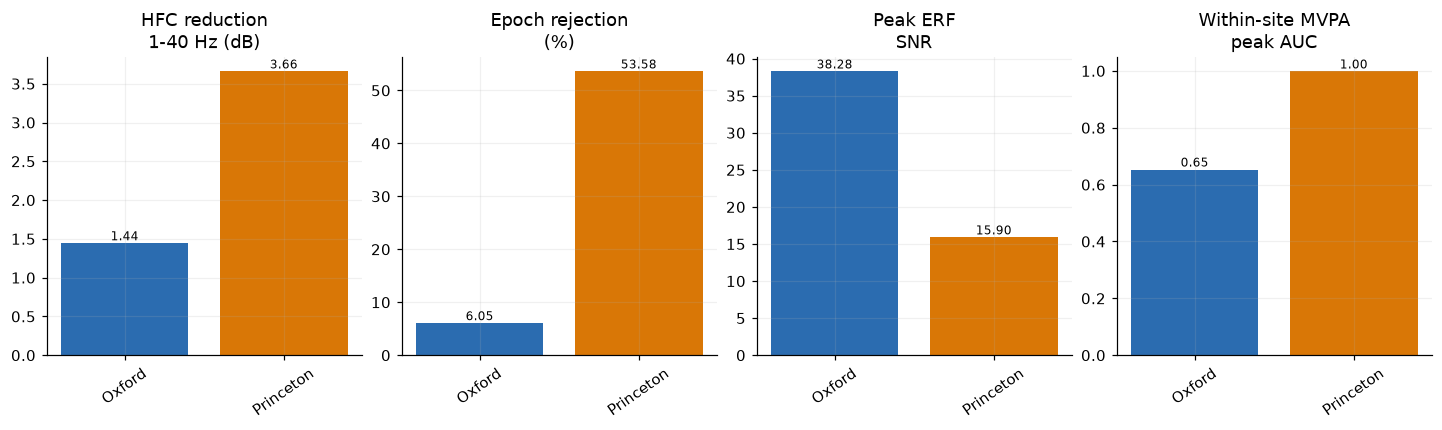

Saved: outputs/flux_oxford_princeton/princeton_sub-038/10_integrated_quality_summary.png


### Reading the result

- HFC benefit should be interpreted together with absolute post-HFC PSD and mains excess.
- Blink and muscle rates describe both participant behaviour and detector sensitivity.
- Epoch retention controls the effective sample size of ERF/TFR comparisons.
- ERF SNR and beta modulation are closer to functional signal-quality measures, but the paradigms are not identical.
- MVPA is intentionally within-dataset and balanced to 138 trials per class; it is not a classifier of recording site.

All PNGs and the numeric table were written to `outputs/flux_oxford_princeton/princeton_sub-038`.

In [16]:
rows = []
for name in raws:
    row = {
        "dataset": name,
        "manual_or_metadata_bad_channels": len(
            set(raws[name].info["bads"]) - set(sensor_qc[name]["auto_bad"])
        ),
        "automatic_power_outliers": len(sensor_qc[name]["auto_bad"]),
        "mean_PSD_after_HFC_dB": hfc_diagnostics[name]["psd_after_db"],
        "HFC_reduction_1_40_dB": hfc_diagnostics[name]["hfc_reduction_db_1_40"],
        "line_excess_after_HFC_dB": hfc_diagnostics[name]["line_excess_db_after"],
        "blink_detector_channel": artifact_stats[name]["eog_channel"],
        "blinks_per_min": artifact_stats[name]["blinks_per_min"],
        "muscle_percent": artifact_stats[name]["muscle_percent"],
        "epochs_retained": epoch_stats[name]["retained"],
        "epochs_rejected_percent": epoch_stats[name]["rejected_percent"],
        "epochs_dropped_blink": epoch_stats[name]["dropped_blink"],
        "epochs_dropped_muscle": epoch_stats[name]["dropped_muscle"],
        "epochs_dropped_amplitude": epoch_stats[name]["dropped_amplitude"],
        "baseline_RMS_fT": erf_metrics[name]["baseline_rms_fT"],
        "peak_ERF_SNR": erf_metrics[name]["peak_response_snr"],
        "beta_rebound_percent": beta_metrics[name]["rebound_beta_percent"],
        "within_dataset_peak_MVPA_AUC": float(mvpa_results[name]["scores"].max()),
    }
    rows.append(row)
quality = pd.DataFrame(rows).set_index("dataset")
quality.to_csv(FIG_DIR / "quality_metrics.csv")
display(quality.round(3))

plot_metrics = {
    "HFC reduction\n1-40 Hz (dB)": "HFC_reduction_1_40_dB",
    "Epoch rejection\n(%)": "epochs_rejected_percent",
    "Peak ERF\nSNR": "peak_ERF_SNR",
    "Within-site MVPA\npeak AUC": "within_dataset_peak_MVPA_AUC",
}
fig, axes = plt.subplots(1, 4, figsize=(13, 3.8), constrained_layout=True)
for ax, (label, col) in zip(axes, plot_metrics.items()):
    vals = quality[col]
    ax.bar(vals.index, vals.values, color=[COLORS[x] for x in vals.index])
    ax.set_title(label)
    ax.tick_params(axis="x", rotation=35)
    for i, v in enumerate(vals):
        ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
save_show(fig, "10_integrated_quality_summary")

display(
    Markdown(
        "### Reading the result\n\n"
        "- HFC benefit should be interpreted together with absolute post-HFC PSD and mains excess.\n"
        "- Blink and muscle rates describe both participant behaviour and detector sensitivity.\n"
        "- Epoch retention controls the effective sample size of ERF/TFR comparisons.\n"
        "- ERF SNR and beta modulation are closer to functional signal-quality measures, but the paradigms are not identical.\n"
        f"- MVPA is intentionally within-dataset and balanced to {global_n} trials per class; it is not a classifier of recording site.\n\n"
        f"All PNGs and the numeric table were written to `{FIG_DIR.relative_to(ROOT)}`."
    )
)

## References and reproducibility notes

1. Rakshit, A., Ghafari, T., Kowalczyk, A., & Jensen, O. (2026). *OPM-FLUX: A Pipeline for OPM MEG Data Analysis*. bioRxiv. https://doi.org/10.64898/2026.04.24.720604
2. Tierney, T. M. et al. (2021). Modelling optically pumped magnetometer interference in MEG as a spatially homogeneous magnetic field. *NeuroImage, 244*, 118484.
3. Gross, J. et al. (2001). Dynamic imaging of coherent sources. *PNAS, 98*, 694-699.
4. Van Veen, B. D. et al. (1997). Localization of brain electrical activity via linearly constrained minimum variance spatial filtering. *IEEE TBME, 44*, 867-880.

Re-run notes:

- Execute from the repository root so the relative data paths resolve.
- To switch Princeton participant, edit only `PRINCETON_DATASET` in the setup cell; outputs are separated by that folder name.
- `RUN_ICA` and `RUN_SOURCE_MODELING` are explicit switches in the setup cell.
- `SHARED_BLINK_DETECTOR` selects the channel used for blink annotation and ICA-EOG selection (shared frontal OPM surrogate, or Princeton's native EOG). The two modes write to separate output folders.
- Re-run the entire notebook after changing preprocessing settings; later cells depend on objects generated earlier.
- LCMV and DICS maps are displayed on each participant's T1 MRI. LCMV peak parcels come from the participant's `aparc+aseg.mgz`, and peak coordinates are also reported in MNI space via the supplied FreeSurfer Talairach transforms. No extra Princeton-specific `fsaverage` is needed for these plots.
- Before inferential source analysis, visually verify both MRI/head coregistrations. For voxelwise group statistics, install a common template such as FreeSurfer `fsaverage` and morph/interpolate both volume estimates onto the same grid.
